In [28]:
from google.colab import files

uploaded = files.upload()

Saving master_bengaluru_accidents_2018_2024.csv to master_bengaluru_accidents_2018_2024 (1).csv


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

In [31]:
df = pd.read_csv("master_bengaluru_accidents_2018_2024.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (333, 11)


In [32]:
df.head(10)

,Zone,Sub-division,Station,Year,Fatal,Killed,Non-Fatal,Injured,Total,Fatal_Rate,NonFatal_Rate
0,East,NaN,Adugodi,2018,3,3.0,47,53.0,50,0.060000,0.940000
1,East,NaN,Adugodi,2019,6,6.0,56,55.0,62,0.096774,0.903226
2,East,NaN,Adugodi,2020,2,2.0,27,30.0,29,0.068966,0.931034
3,East,NaN,Adugodi,2021,2,8.0,17,20.0,19,0.105263,0.894737
4,East,NaN,Adugodi,2022,6,6.0,36,41.0,42,0.142857,0.857143
5,South,South East,Adugodi,2023,10,10.0,53,67.0,63,0.158730,0.841270
6,South,South East,Adugodi,2024,5,NaN,45,NaN,50,0.100000,0.900000
7,East,NaN,Airport,2018,24,26.0,85,77.0,109,0.220183,0.779817
8,East,NaN,Airport,2019,16,16.0,68,59.0,84,0.190476,0.809524
9,East,NaN,Airport,2020,19,19.0,45,40.0,64,0.296875,0.703125


In [33]:
print(df.columns.tolist())

['Zone', 'Sub-division', 'Station', 'Year', 'Fatal', 'Killed', 'Non-Fatal', 'Injured', 'Total', 'Fatal_Rate', 'NonFatal_Rate']


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Zone           328 non-null    object 
 1   Sub-division   98 non-null     object 
 2   Station        333 non-null    object 
 3   Year           333 non-null    int64  
 4   Fatal          333 non-null    int64  
 5   Killed         278 non-null    float64
 6   Non-Fatal      333 non-null    int64  
 7   Injured        278 non-null    float64
 8   Total          333 non-null    int64  
 9   Fatal_Rate     333 non-null    float64
 10  NonFatal_Rate  333 non-null    float64
dtypes: float64(4), int64(4), object(3)
memory usage: 28.7+ KB


In [35]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Values,Percentage
Zone,5,1.50
Sub-division,235,70.57
Station,0,0.00
Year,0,0.00
Fatal,0,0.00
Killed,55,16.52
Non-Fatal,0,0.00
Injured,55,16.52
Total,0,0.00
Fatal_Rate,0,0.00


In [36]:
df.describe()

,Year,Fatal,Killed,Non-Fatal,Injured,Total,Fatal_Rate,NonFatal_Rate
count,333.000000,333.000000,278.000000,333.000000,278.000000,333.000000,333.000000,333.000000
mean,2021.138138,36.042042,35.165468,169.519520,168.859712,205.561562,0.171079,0.828921
std,2.035562,108.963731,109.591371,513.886881,529.906332,621.879443,0.068503,0.068503
min,2018.000000,0.000000,1.000000,5.000000,4.000000,7.000000,0.000000,0.473684
25%,2019.000000,6.000000,6.000000,42.000000,41.000000,50.000000,0.125000,0.790698
50%,2021.000000,13.000000,13.000000,67.000000,66.000000,81.000000,0.166667,0.833333
75%,2023.000000,24.000000,24.750000,110.000000,115.750000,137.000000,0.209302,0.875000
max,2024.000000,882.000000,910.000000,4092.000000,4250.000000,4974.000000,0.526316,1.000000


In [37]:
print("Years available:")
print(sorted(df["Year"].unique()))

Years available:
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [38]:
print("Number of unique stations:", df["Station"].nunique())

Number of unique stations: 70


In [39]:
yearly_accidents = (
    df.groupby("Year")["Total"]
    .sum()
    .reset_index()
)

yearly_accidents

,Year,Total
0,2018,9222
1,2019,9368
2,2020,6472
3,2021,6422
4,2022,7646
5,2023,14922
6,2024,14400


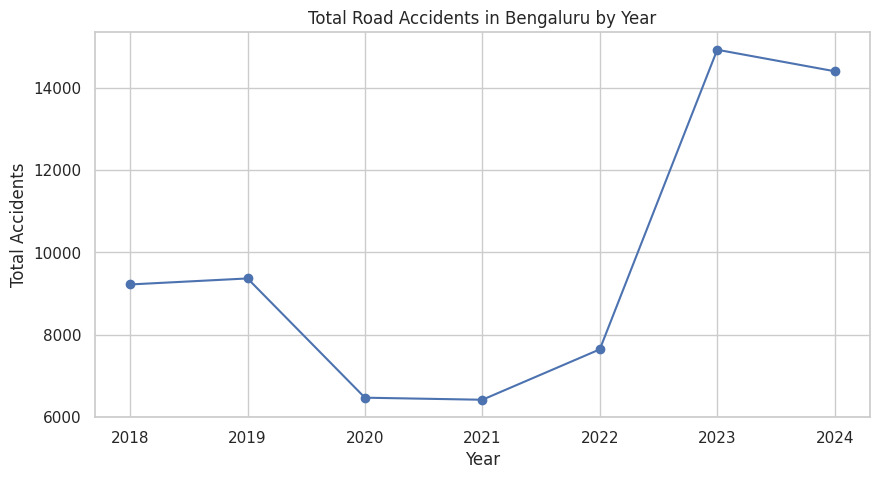

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_accidents["Year"],
    yearly_accidents["Total"],
    marker="o"
)

plt.title("Total Road Accidents in Bengaluru by Year")
plt.xlabel("Year")
plt.ylabel("Total Accidents")
plt.xticks(yearly_accidents["Year"])

plt.show()

In [41]:
###Fatal vs non-fatal accidents by year
yearly_severity = (
    df.groupby("Year")[["Fatal", "Non-Fatal"]]
    .sum()
    .reset_index()
)

yearly_severity

,Year,Fatal,Non-Fatal
0,2018,1326,7896
1,2019,1492,7876
2,2020,1244,5228
3,2021,1236,5186
4,2022,1502,6144
5,2023,2646,12276
6,2024,2556,11844


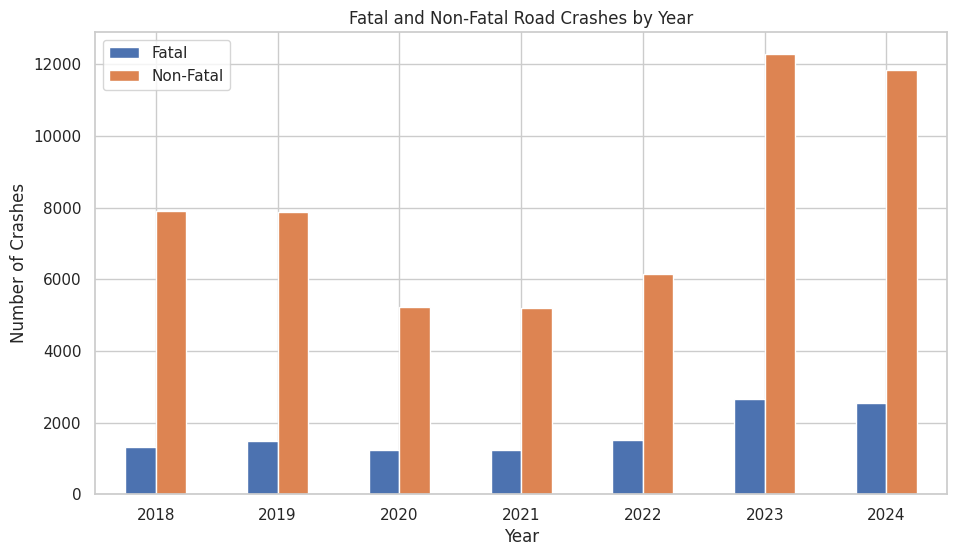

In [42]:
yearly_severity.plot(
    x="Year",
    y=["Fatal", "Non-Fatal"],
    kind="bar",
    figsize=(11, 6)
)

plt.title("Fatal and Non-Fatal Road Crashes by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")

plt.xticks(rotation=0)

plt.show()

In [43]:
###Top 10 accident-prone stations
# Remove aggregate/summary rows from Station column
exclude_stations = [
    "Grand Total",
    "Grand total",
    "grand total",
    "Total",
    "TOTAL",
    "total"
]

df = df[~df["Station"].astype(str).str.strip().isin(exclude_stations)].copy()

# Check remaining station names
print("Number of unique stations:", df["Station"].nunique())

# Top 10 accident-prone stations
top_stations = (
    df.groupby("Station")["Total"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 actual accident-prone stations:")
display(top_stations)

Number of unique stations: 69
Top 10 actual accident-prone stations:


,Total
Station,
North Total,3081
West Total,2407
South Total,2299
East Total,1987
Kamakshipalya,1329
Peenya,1201
Electronic City,1127
Kengeri,1102
Yelahanka,1052


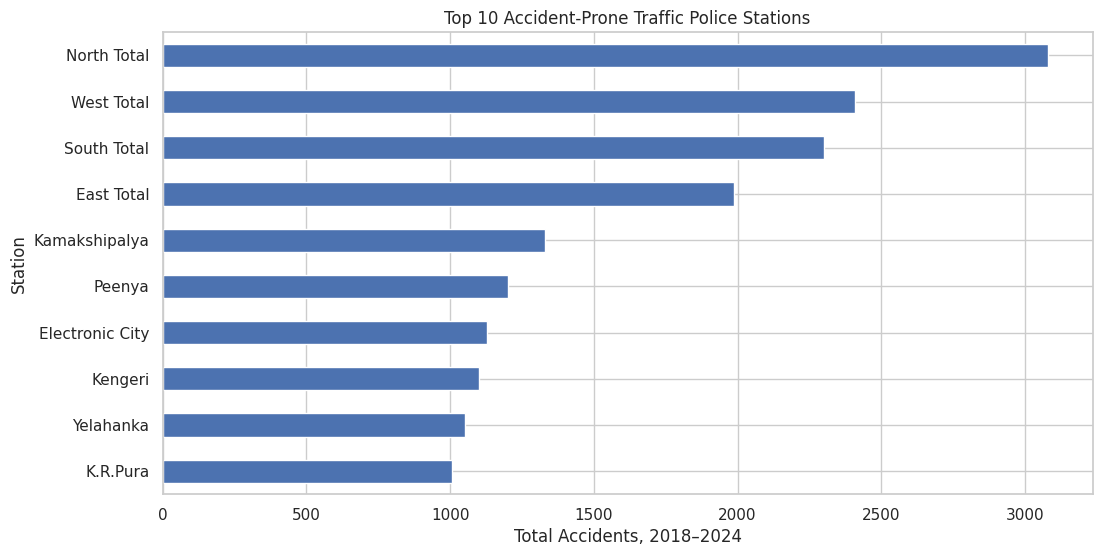

In [44]:
plt.figure(figsize=(12, 6))

top_stations.sort_values().plot(kind="barh")

plt.title("Top 10 Accident-Prone Traffic Police Stations")
plt.xlabel("Total Accidents, 2018–2024")
plt.ylabel("Station")

plt.show()

In [45]:
top_fatal_stations = (
    df.groupby("Station")["Fatal"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 stations by fatal crashes:")
display(top_fatal_stations)

Top 10 stations by fatal crashes:


,Fatal
Station,
North Total,642
South Total,390
West Total,366
East Total,336
Yelahanka,231
Electronic City,223
Kengeri,217
Kamakshipalya,211
K.R.Pura,195


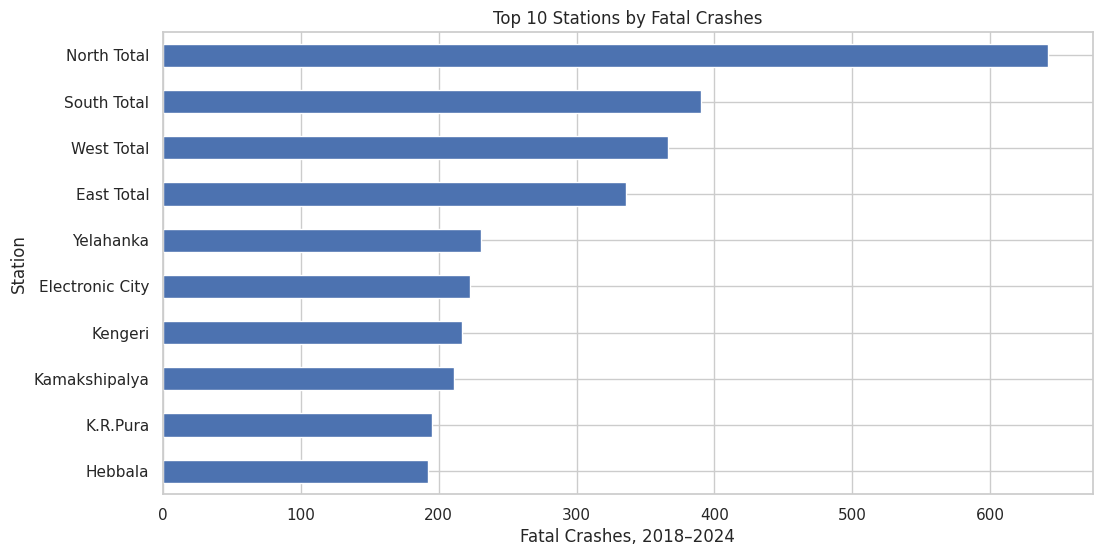

In [46]:
plt.figure(figsize=(12, 6))

top_fatal_stations.sort_values().plot(kind="barh")

plt.title("Top 10 Stations by Fatal Crashes")
plt.xlabel("Fatal Crashes, 2018–2024")
plt.ylabel("Station")

plt.show()

In [47]:
station_summary = (
    df.groupby("Station")
    .agg(
        Total_Accidents=("Total", "sum"),
        Fatal_Crashes=("Fatal", "sum"),
        NonFatal_Crashes=("Non-Fatal", "sum"),
        Average_Annual_Accidents=("Total", "mean")
    )
    .reset_index()
)

station_summary["Fatal_Rate"] = (
    station_summary["Fatal_Crashes"] /
    station_summary["Total_Accidents"]
)

station_summary = station_summary.sort_values(
    "Total_Accidents",
    ascending=False
)

display(station_summary.head(15))

,Station,Total_Accidents,Fatal_Crashes,NonFatal_Crashes,Average_Annual_Accidents,Fatal_Rate
47,North Total,3081,642,2439,1540.500000,0.208374
62,West Total,2407,366,2041,1203.500000,0.152057
55,South Total,2299,390,1909,1149.500000,0.169639
18,East Total,1987,336,1651,993.500000,0.169099
38,Kamakshipalya,1329,211,1118,189.857143,0.158766
48,Peenya,1201,184,1017,171.571429,0.153206
19,Electronic City,1127,223,904,161.000000,0.197870
39,Kengeri,1102,217,885,157.428571,0.196915
68,Yelahanka,1052,231,821,210.400000,0.219582
36,K.R.Pura,1005,195,810,201.000000,0.194030


In [48]:
station_summary.sort_values(
    "Total_Accidents",
    ascending=False
).head(15)

,Station,Total_Accidents,Fatal_Crashes,NonFatal_Crashes,Average_Annual_Accidents,Fatal_Rate
47,North Total,3081,642,2439,1540.500000,0.208374
62,West Total,2407,366,2041,1203.500000,0.152057
55,South Total,2299,390,1909,1149.500000,0.169639
18,East Total,1987,336,1651,993.500000,0.169099
38,Kamakshipalya,1329,211,1118,189.857143,0.158766
48,Peenya,1201,184,1017,171.571429,0.153206
19,Electronic City,1127,223,904,161.000000,0.197870
39,Kengeri,1102,217,885,157.428571,0.196915
68,Yelahanka,1052,231,821,210.400000,0.219582
36,K.R.Pura,1005,195,810,201.000000,0.194030


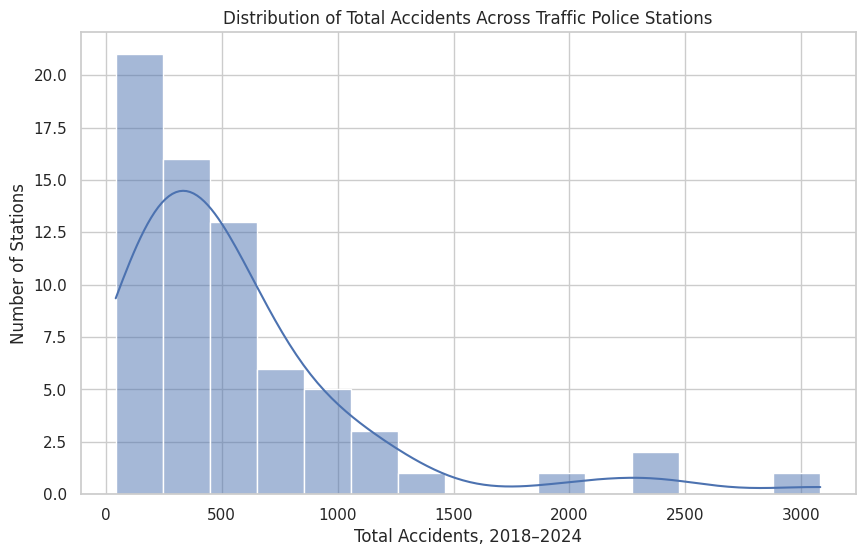

In [49]:
plt.figure(figsize=(10, 6))

sns.histplot(
    station_summary["Total_Accidents"],
    bins=15,
    kde=True
)

plt.title("Distribution of Total Accidents Across Traffic Police Stations")
plt.xlabel("Total Accidents, 2018–2024")
plt.ylabel("Number of Stations")

plt.show()

In [50]:
station_year = df.pivot_table(
    index="Station",
    columns="Year",
    values="Total",
    aggfunc="sum"
)

top20 = (
    station_summary
    .sort_values("Total_Accidents", ascending=False)
    .head(20)["Station"]
)

heatmap_data = station_year.loc[top20]

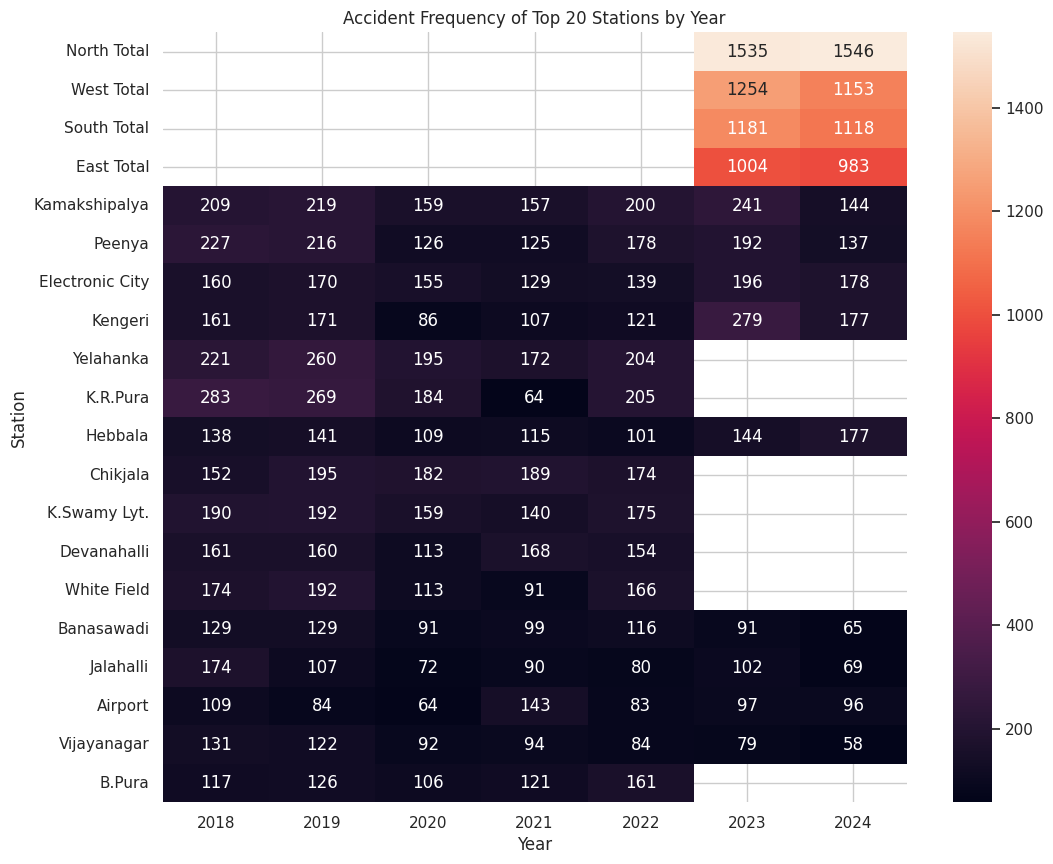

In [51]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f"
)

plt.title("Accident Frequency of Top 20 Stations by Year")
plt.xlabel("Year")
plt.ylabel("Station")

plt.show()

In [52]:
df["Yearly_Rank"] = (
    df.groupby("Year")["Total"]
      .rank(
          ascending=False,
          method="min"
      )
)

In [53]:
consistent_hotspots = (
    df[df["Yearly_Rank"] <= 10]
    .groupby("Station")
    .size()
    .sort_values(ascending=False)
)

display(consistent_hotspots.head(15))

,0
Station,
Electronic City,6
Kamakshipalya,6
Peenya,5
Yelahanka,5
K.Swamy Lyt.,5
Devanahalli,5
Kengeri,4
White Field,4
K.R.Pura,4


In [54]:
station_summary.to_csv(
    "station_accident_summary.csv",
    index=False
)

print("Station summary saved!")

Station summary saved!


In [55]:
yearly_accidents.to_csv(
    "yearly_accident_summary.csv",
    index=False
)

print("Yearly summary saved!")

Yearly summary saved!


In [56]:
# Remove all aggregate/summary rows from Station
df = df[
    ~df["Station"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.contains("total", na=False)
].copy()

print("Remaining number of stations:", df["Station"].nunique())

# Check whether any Total rows remain
print("\nRows containing 'total':")
print(
    df[
        df["Station"]
        .astype(str)
        .str.lower()
        .str.contains("total", na=False)
    ]["Station"].unique()
)

Remaining number of stations: 65

Rows containing 'total':
[]


In [57]:
# Look for station names containing Whitefield / White Field
df[
    df["Station"]
    .astype(str)
    .str.lower()
    .str.contains("white", na=False)
]["Station"].unique()

array(['White Field', 'Whitefield'], dtype=object)

In [58]:
df["Station"] = df["Station"].replace({
    "White Field": "Whitefield"
})

PHASE 2 — Exploratory Data Analysis

In [59]:
print("Dataset shape:", df.shape)
print("Number of stations:", df["Station"].nunique())
print("Years:", sorted(df["Year"].unique()))

print("\nAggregate rows still present:")
print(
    df[
        df["Station"]
        .astype(str)
        .str.lower()
        .str.contains("total", na=False)
    ]["Station"].unique()
)

Dataset shape: (318, 12)
Number of stations: 64
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Aggregate rows still present:
[]


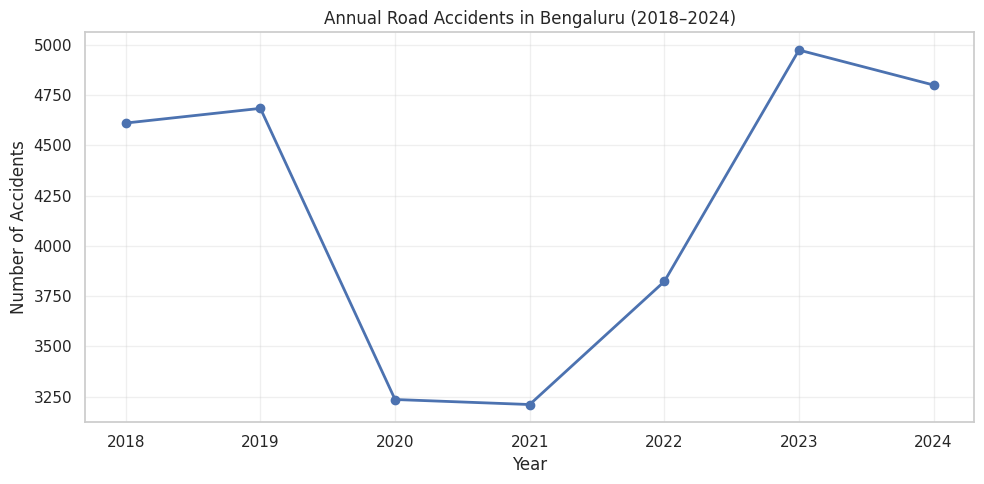

In [60]:
yearly_accidents = (
    df.groupby("Year")["Total"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_accidents["Year"],
    yearly_accidents["Total"],
    marker="o",
    linewidth=2
)

plt.title("Annual Road Accidents in Bengaluru (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.xticks(yearly_accidents["Year"])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
yearly_severity = (
    df.groupby("Year")[["Fatal", "Non-Fatal"]]
    .sum()
    .reset_index()
)

display(yearly_severity)

,Year,Fatal,Non-Fatal
0,2018,663,3948
1,2019,746,3938
2,2020,622,2614
3,2021,618,2593
4,2022,751,3072
5,2023,882,4092
6,2024,852,3948


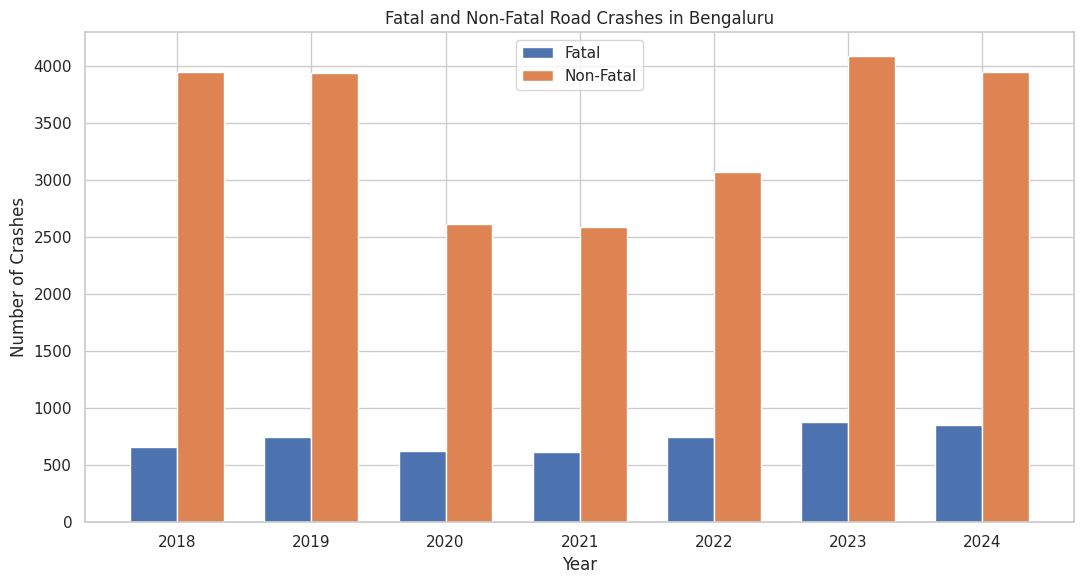

In [62]:
plt.figure(figsize=(11, 6))

x = np.arange(len(yearly_severity))
width = 0.35

plt.bar(
    x - width/2,
    yearly_severity["Fatal"],
    width,
    label="Fatal"
)

plt.bar(
    x + width/2,
    yearly_severity["Non-Fatal"],
    width,
    label="Non-Fatal"
)

plt.xticks(x, yearly_severity["Year"])
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.title("Fatal and Non-Fatal Road Crashes in Bengaluru")
plt.legend()

plt.tight_layout()
plt.show()

In [63]:
top_stations = (
    df.groupby("Station")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_stations)

,Total
Station,
Kamakshipalya,1329
Peenya,1201
Whitefield,1148
Electronic City,1127
Kengeri,1102
Yelahanka,1052
K.R.Pura,1005
Hebbala,925
Chikjala,892


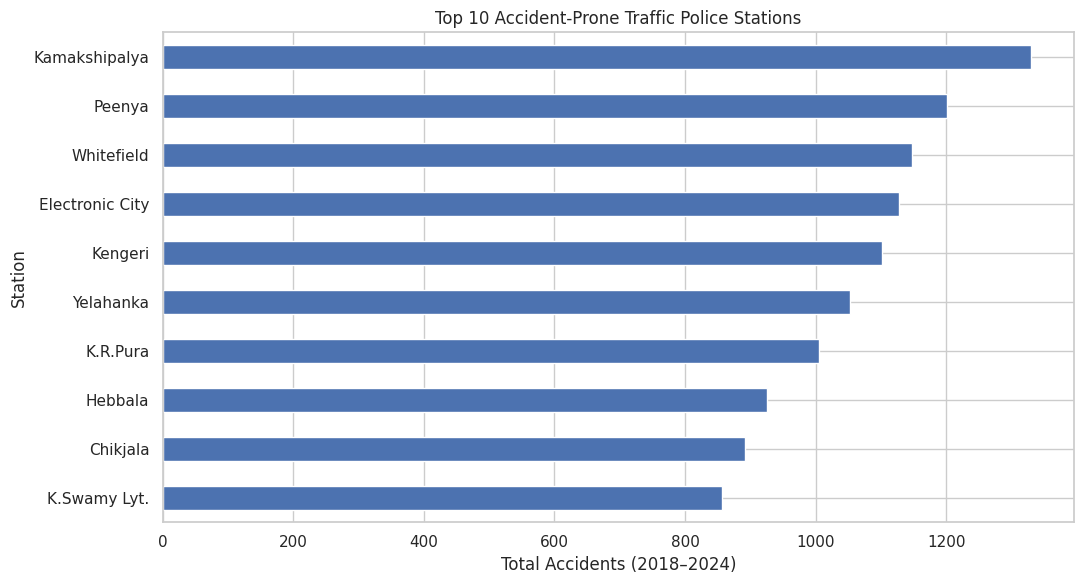

In [64]:
plt.figure(figsize=(11, 6))

top_stations.sort_values().plot(kind="barh")

plt.title("Top 10 Accident-Prone Traffic Police Stations")
plt.xlabel("Total Accidents (2018–2024)")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

In [65]:
top_fatal_stations = (
    df.groupby("Station")["Fatal"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_fatal_stations)

,Fatal
Station,
Whitefield,243
Yelahanka,231
Electronic City,223
Kengeri,217
Kamakshipalya,211
K.R.Pura,195
Hebbala,192
Peenya,184
Chikjala,183


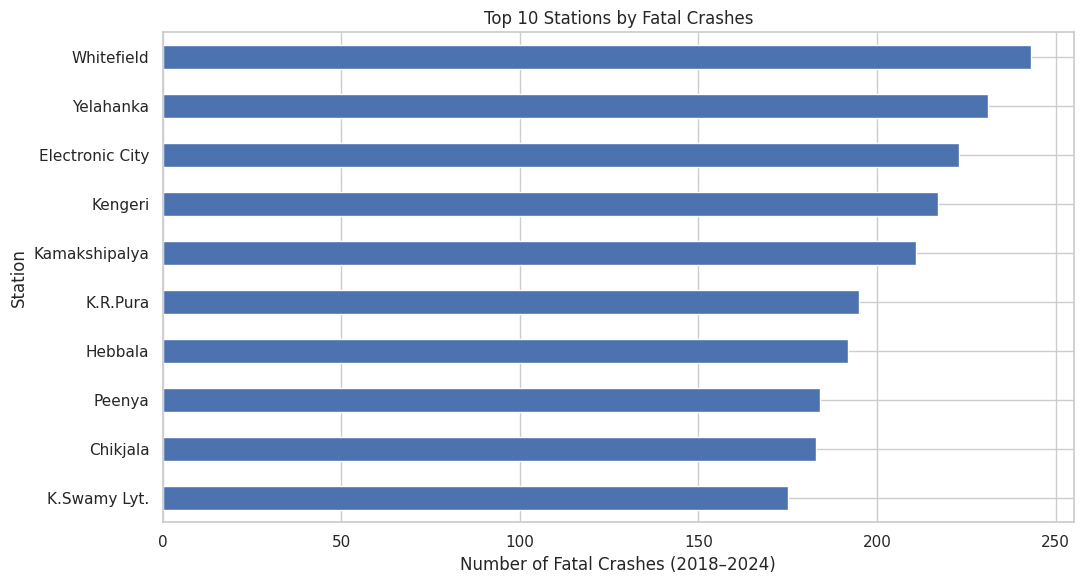

In [66]:
plt.figure(figsize=(11, 6))

top_fatal_stations.sort_values().plot(kind="barh")

plt.title("Top 10 Stations by Fatal Crashes")
plt.xlabel("Number of Fatal Crashes (2018–2024)")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

In [67]:
station_summary = (
    df.groupby("Station")
    .agg(
        Total_Accidents=("Total", "sum"),
        Fatal_Crashes=("Fatal", "sum"),
        NonFatal_Crashes=("Non-Fatal", "sum"),
        Average_Annual_Accidents=("Total", "mean")
    )
    .reset_index()
)

station_summary["Fatal_Rate"] = (
    station_summary["Fatal_Crashes"] /
    station_summary["Total_Accidents"]
)

station_summary["Fatal_Rate_Percent"] = (
    station_summary["Fatal_Rate"] * 100
)

station_summary = station_summary.sort_values(
    "Total_Accidents",
    ascending=False
)

display(station_summary.head(15))

,Station,Total_Accidents,Fatal_Crashes,NonFatal_Crashes,Average_Annual_Accidents,Fatal_Rate,Fatal_Rate_Percent
37,Kamakshipalya,1329,211,1118,189.857143,0.158766,15.876599
46,Peenya,1201,184,1017,171.571429,0.153206,15.320566
59,Whitefield,1148,243,905,164.000000,0.211672,21.167247
18,Electronic City,1127,223,904,161.000000,0.197870,19.787045
38,Kengeri,1102,217,885,157.428571,0.196915,19.691470
63,Yelahanka,1052,231,821,210.400000,0.219582,21.958175
35,K.R.Pura,1005,195,810,201.000000,0.194030,19.402985
23,Hebbala,925,192,733,132.142857,0.207568,20.756757
12,Chikjala,892,183,709,178.400000,0.205157,20.515695
36,K.Swamy Lyt.,856,175,681,171.200000,0.204439,20.443925


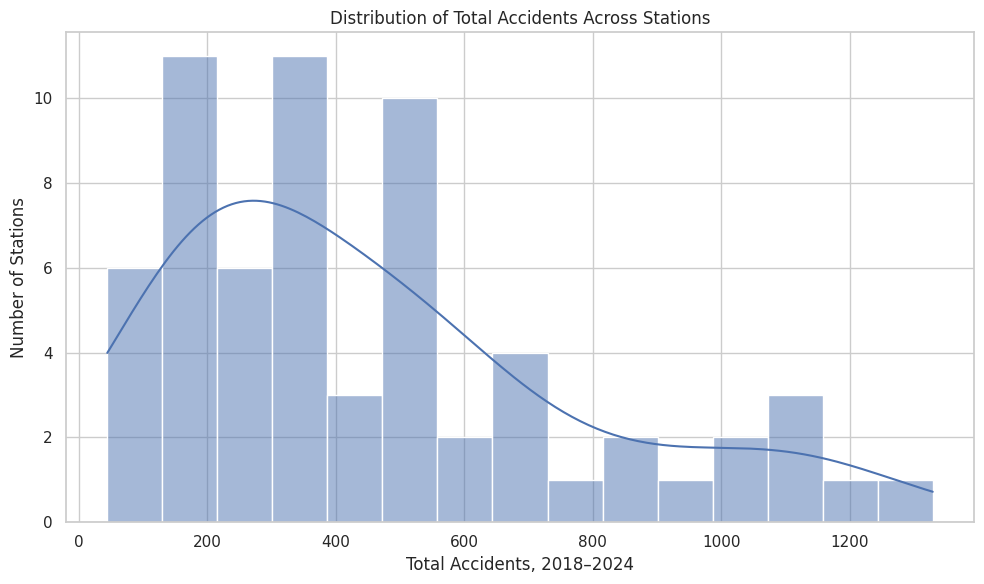

In [68]:
plt.figure(figsize=(10, 6))

sns.histplot(
    station_summary["Total_Accidents"],
    bins=15,
    kde=True
)

plt.title("Distribution of Total Accidents Across Stations")
plt.xlabel("Total Accidents, 2018–2024")
plt.ylabel("Number of Stations")

plt.tight_layout()
plt.show()

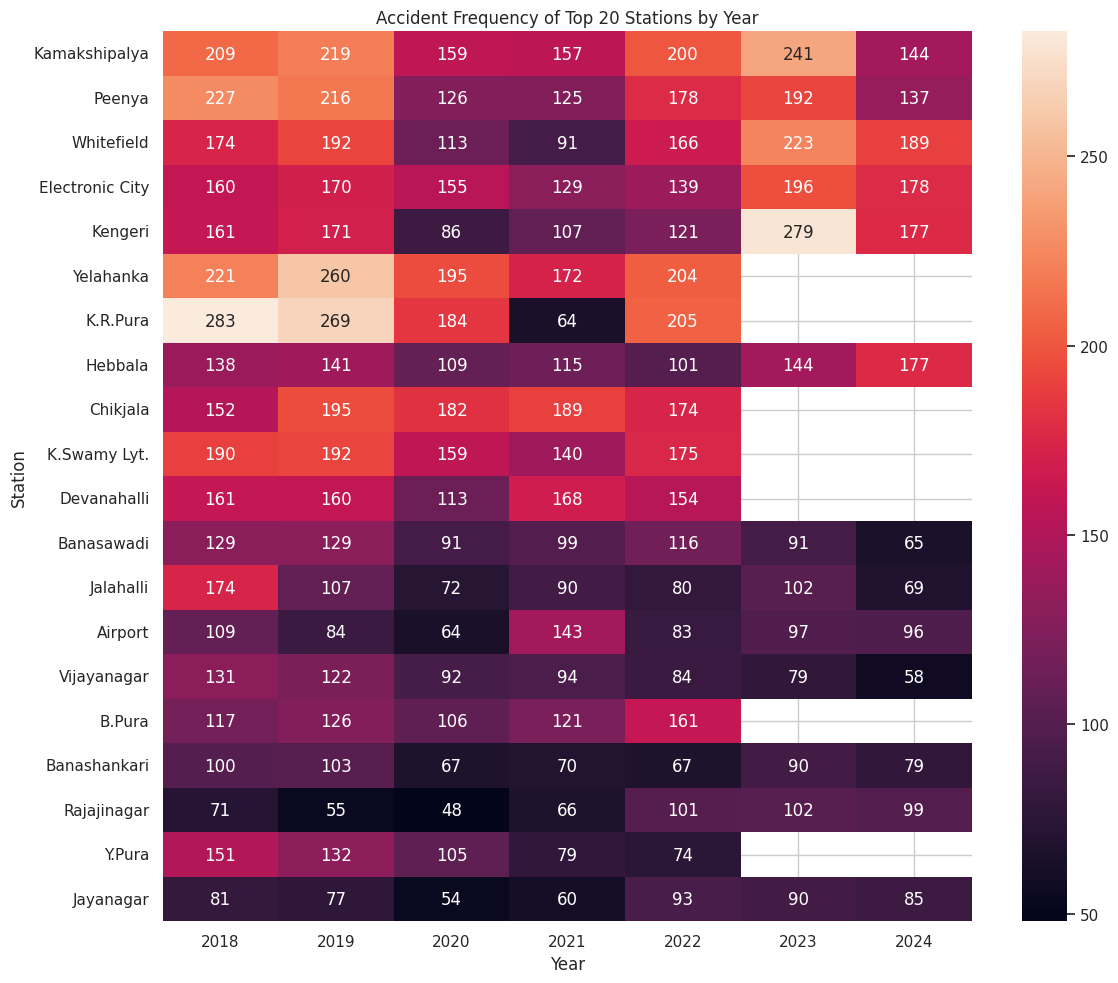

In [69]:
station_year = df.pivot_table(
    index="Station",
    columns="Year",
    values="Total",
    aggfunc="sum"
)

top20 = (
    station_summary
    .head(20)["Station"]
)

heatmap_data = station_year.loc[top20]

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f"
)

plt.title("Accident Frequency of Top 20 Stations by Year")
plt.xlabel("Year")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

In [70]:
df["Yearly_Rank"] = (
    df.groupby("Year")["Total"]
    .rank(
        ascending=False,
        method="min"
    )
)

consistent_hotspots = (
    df[df["Yearly_Rank"] <= 10]
    .groupby("Station")
    .size()
    .sort_values(ascending=False)
)

display(consistent_hotspots.head(15))

,0
Station,
Kamakshipalya,7
Electronic City,7
Whitefield,6
Peenya,6
K.Swamy Lyt.,5
Devanahalli,5
Yelahanka,5
Chikjala,4
Kengeri,4


In [71]:
consistency_df = consistent_hotspots.reset_index()

consistency_df.columns = [
    "Station",
    "Years_in_Top10"
]

consistency_df["Consistency_Percent"] = (
    consistency_df["Years_in_Top10"] / 7 * 100
)

display(consistency_df.head(15))

,Station,Years_in_Top10,Consistency_Percent
0,Kamakshipalya,7,100.000000
1,Electronic City,7,100.000000
2,Whitefield,6,85.714286
3,Peenya,6,85.714286
4,K.Swamy Lyt.,5,71.428571
5,Devanahalli,5,71.428571
6,Yelahanka,5,71.428571
7,Chikjala,4,57.142857
8,Kengeri,4,57.142857
9,K.R.Pura,4,57.142857


In [72]:
station_summary.to_csv(
    "station_accident_summary.csv",
    index=False
)

yearly_accidents.to_csv(
    "yearly_accident_summary.csv",
    index=False
)

consistency_df.to_csv(
    "station_hotspot_consistency.csv",
    index=False
)

print("Phase 2 output files saved successfully.")

Phase 2 output files saved successfully.


PHASE 3 — Accident Hotspot Score

In [73]:
print("df shape:", df.shape)
print("station_summary shape:", station_summary.shape)

display(station_summary.head())

df shape: (318, 12)
station_summary shape: (64, 7)


,Station,Total_Accidents,Fatal_Crashes,NonFatal_Crashes,Average_Annual_Accidents,Fatal_Rate,Fatal_Rate_Percent
37,Kamakshipalya,1329,211,1118,189.857143,0.158766,15.876599
46,Peenya,1201,184,1017,171.571429,0.153206,15.320566
59,Whitefield,1148,243,905,164.000000,0.211672,21.167247
18,Electronic City,1127,223,904,161.000000,0.197870,19.787045
38,Kengeri,1102,217,885,157.428571,0.196915,19.691470


In [74]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

station_summary["Frequency_Score"] = scaler.fit_transform(
    station_summary[["Total_Accidents"]]
)

In [75]:
display(
    station_summary[
        [
            "Station",
            "Total_Accidents",
            "Frequency_Score"
        ]
    ].head(10)
)

,Station,Total_Accidents,Frequency_Score
37,Kamakshipalya,1329,1.000000
46,Peenya,1201,0.900389
59,Whitefield,1148,0.859144
18,Electronic City,1127,0.842802
38,Kengeri,1102,0.823346
63,Yelahanka,1052,0.784436
35,K.R.Pura,1005,0.747860
23,Hebbala,925,0.685603
12,Chikjala,892,0.659922
36,K.Swamy Lyt.,856,0.631907


In [76]:
station_summary["Severity_Score"] = scaler.fit_transform(
    station_summary[["Fatal_Rate"]]
)

In [77]:
display(
    station_summary[
        [
            "Station",
            "Fatal_Crashes",
            "Fatal_Rate",
            "Severity_Score"
        ]
    ].head(10)
)

,Station,Fatal_Crashes,Fatal_Rate,Severity_Score
37,Kamakshipalya,211,0.158766,0.276984
46,Peenya,184,0.153206,0.258608
59,Whitefield,243,0.211672,0.451823
18,Electronic City,223,0.197870,0.406212
38,Kengeri,217,0.196915,0.403053
63,Yelahanka,231,0.219582,0.477961
35,K.R.Pura,195,0.194030,0.393520
23,Hebbala,192,0.207568,0.438258
12,Chikjala,183,0.205157,0.430291
36,K.Swamy Lyt.,175,0.204439,0.427919


In [78]:
df["Yearly_Rank"] = (
    df.groupby("Year")["Total"]
      .rank(
          ascending=False,
          method="min"
      )
)

In [79]:
consistency = (
    df.assign(
        In_Top10=df["Yearly_Rank"] <= 10
    )
    .groupby("Station")
    .agg(
        Years_In_Top10=("In_Top10", "sum"),
        Years_Observed=("Year", "nunique")
    )
    .reset_index()
)

In [80]:
display(consistency.head(15))

,Station,Years_In_Top10,Years_Observed
0,Adugodi,0,7
1,Airport,1,7
2,Ashokanagar,0,7
3,B.Pura,2,5
4,Banasawadi,0,7
5,Banashankari,0,7
6,Basavanagudi,0,7
7,Bellanduru,0,2
8,Bytarayanapura,2,2
9,Chamarajapet,0,5


In [81]:
consistency["Consistency_Percent"] = (
    consistency["Years_In_Top10"] /
    consistency["Years_Observed"] *
    100
)

In [82]:
display(
    consistency.sort_values(
        "Consistency_Percent",
        ascending=False
    ).head(15)
)

,Station,Years_In_Top10,Years_Observed,Consistency_Percent
8,Bytarayanapura,2,2,100.000000
28,Int. Aiport,2,2,100.000000
18,Electronic City,7,7,100.000000
17,Devanahalli,5,5,100.000000
31,Jnanabharathi,1,1,100.000000
37,Kamakshipalya,7,7,100.000000
36,K.Swamy Lyt.,5,5,100.000000
33,K R Puram,2,2,100.000000
61,Yalahanka,2,2,100.000000
63,Yelahanka,5,5,100.000000


In [83]:
consistency["Consistency_Score"] = scaler.fit_transform(
    consistency[["Consistency_Percent"]]
)

In [84]:
historical = (
    df[df["Year"] <= 2022]
    .groupby("Station")["Total"]
    .mean()
    .reset_index(name="Historical_Avg")
)

In [85]:
recent = (
    df[df["Year"] >= 2023]
    .groupby("Station")["Total"]
    .mean()
    .reset_index(name="Recent_Avg")
)

In [86]:
trend = historical.merge(
    recent,
    on="Station",
    how="outer"
)

display(trend.head())

,Station,Historical_Avg,Recent_Avg
0,Adugodi,40.4,56.5
1,Airport,96.6,96.5
2,Ashokanagar,47.2,36.5
3,B.Pura,126.2,NaN
4,Banasawadi,112.8,78.0


In [87]:
trend["Recent_Trend_Percent"] = (
    (trend["Recent_Avg"] - trend["Historical_Avg"])
    / trend["Historical_Avg"].replace(0, np.nan)
) * 100

In [88]:
display(
    trend.sort_values(
        "Recent_Trend_Percent",
        ascending=False
    ).head(15)
)

,Station,Historical_Avg,Recent_Avg,Recent_Trend_Percent
15,City Market,14.8,37.0,150.000000
32,K G Halli,24.8,47.0,89.516129
38,Kengeri,129.2,228.0,76.470588
27,Indiranagar,62.2,102.0,63.987138
54,U.Gate,38.6,61.0,58.031088
6,Basavanagudi,63.0,96.0,52.380952
50,Rajajinagar,68.2,100.5,47.360704
40,Magadi Road,31.0,45.0,45.161290
39,Madivala,62.0,87.5,41.129032
59,Whitefield,147.2,206.0,39.945652


In [89]:
trend["Recent_Trend_Capped"] = (
    trend["Recent_Trend_Percent"]
    .clip(lower=-100, upper=200)
)

In [90]:
trend["Trend_Score"] = scaler.fit_transform(
    trend[["Recent_Trend_Capped"]]
)

In [91]:
hotspot_df = station_summary.merge(
    consistency[
        [
            "Station",
            "Years_In_Top10",
            "Years_Observed",
            "Consistency_Percent",
            "Consistency_Score"
        ]
    ],
    on="Station",
    how="left"
)

hotspot_df = hotspot_df.merge(
    trend[
        [
            "Station",
            "Historical_Avg",
            "Recent_Avg",
            "Recent_Trend_Percent",
            "Recent_Trend_Capped",
            "Trend_Score"
        ]
    ],
    on="Station",
    how="left"
)

In [92]:
display(hotspot_df.head())

,Station,Total_Accidents,Fatal_Crashes,NonFatal_Crashes,Average_Annual_Accidents,Fatal_Rate,Fatal_Rate_Percent,Frequency_Score,Severity_Score,Years_In_Top10,Years_Observed,Consistency_Percent,Consistency_Score,Historical_Avg,Recent_Avg,Recent_Trend_Percent,Recent_Trend_Capped,Trend_Score
0,Kamakshipalya,1329,211,1118,189.857143,0.158766,15.876599,1.000000,0.276984,7,7,100.000000,1.000000,188.8,192.5,1.959746,1.959746,0.197668
1,Peenya,1201,184,1017,171.571429,0.153206,15.320566,0.900389,0.258608,6,7,85.714286,0.857143,174.4,164.5,-5.676606,-5.676606,0.156281
2,Whitefield,1148,243,905,164.000000,0.211672,21.167247,0.859144,0.451823,6,7,85.714286,0.857143,147.2,206.0,39.945652,39.945652,0.403540
3,Electronic City,1127,223,904,161.000000,0.197870,19.787045,0.842802,0.406212,7,7,100.000000,1.000000,150.6,187.0,24.169987,24.169987,0.318040
4,Kengeri,1102,217,885,157.428571,0.196915,19.691470,0.823346,0.403053,4,7,57.142857,0.571429,129.2,228.0,76.470588,76.470588,0.601493


In [93]:
print(
    hotspot_df[
        [
            "Frequency_Score",
            "Severity_Score",
            "Consistency_Score",
            "Trend_Score"
        ]
    ].isnull().sum()
)

Frequency_Score       0
Severity_Score        0
Consistency_Score     0
Trend_Score          34
dtype: int64


In [94]:
missing_trend = hotspot_df[
    hotspot_df["Trend_Score"].isna()
][
    [
        "Station",
        "Historical_Avg",
        "Recent_Avg",
        "Recent_Trend_Percent"
    ]
]

display(missing_trend)

,Station,Historical_Avg,Recent_Avg,Recent_Trend_Percent
5,Yelahanka,210.4,NaN,NaN
6,K.R.Pura,201.0,NaN,NaN
8,Chikjala,178.4,NaN,NaN
9,K.Swamy Lyt.,171.2,NaN,NaN
10,Devanahalli,151.2,NaN,NaN
15,B.Pura,126.2,NaN,NaN
18,Y.Pura,108.2,NaN,NaN
20,HuliMavu,105.2,NaN,NaN
24,K R Puram,NaN,247.5,NaN
26,Yalahanka,NaN,239.0,NaN


In [95]:
# Fill missing trend scores with a neutral value
# 0.5 means we have insufficient evidence to say
# the station is strongly increasing or decreasing.

hotspot_df["Trend_Score"] = (
    hotspot_df["Trend_Score"]
    .fillna(0.5)
)

print("Missing Trend Scores after correction:")
print(hotspot_df["Trend_Score"].isna().sum())

Missing Trend Scores after correction:
0


In [96]:
print(
    hotspot_df[
        [
            "Frequency_Score",
            "Severity_Score",
            "Consistency_Score",
            "Trend_Score"
        ]
    ].isnull().sum()
)

Frequency_Score      0
Severity_Score       0
Consistency_Score    0
Trend_Score          0
dtype: int64


In [97]:
hotspot_df["Hotspot_Score"] = (
    0.35 * hotspot_df["Frequency_Score"] +
    0.25 * hotspot_df["Severity_Score"] +
    0.20 * hotspot_df["Consistency_Score"] +
    0.20 * hotspot_df["Trend_Score"]
)

In [98]:
hotspot_df["Hotspot_Score_100"] = (
    hotspot_df["Hotspot_Score"] * 100
)

In [99]:
hotspot_df = hotspot_df.sort_values(
    "Hotspot_Score_100",
    ascending=False
).reset_index(drop=True)

hotspot_df["Hotspot_Rank"] = (
    hotspot_df.index + 1
)

In [100]:
low_threshold = hotspot_df["Hotspot_Score_100"].quantile(1/3)
high_threshold = hotspot_df["Hotspot_Score_100"].quantile(2/3)

def classify_hotspot(score):
    if score >= high_threshold:
        return "HIGH"
    elif score >= low_threshold:
        return "MEDIUM"
    else:
        return "LOW"

hotspot_df["Hotspot_Category"] = (
    hotspot_df["Hotspot_Score_100"]
    .apply(classify_hotspot)
)

In [101]:
final_hotspots = hotspot_df[
    [
        "Hotspot_Rank",
        "Station",
        "Total_Accidents",
        "Fatal_Crashes",
        "Fatal_Rate",
        "Years_In_Top10",
        "Consistency_Percent",
        "Recent_Trend_Percent",
        "Hotspot_Score_100",
        "Hotspot_Category"
    ]
]

display(final_hotspots.head(15))

,Hotspot_Rank,Station,Total_Accidents,Fatal_Crashes,Fatal_Rate,Years_In_Top10,Consistency_Percent,Recent_Trend_Percent,Hotspot_Score_100,Hotspot_Category
0,1,Yelahanka,1052,231,0.219582,5,100.000000,NaN,69.404270,HIGH
1,2,Whitefield,1148,243,0.211672,6,85.714286,39.945652,66.579264,HIGH
2,3,Electronic City,1127,223,0.197870,7,100.000000,24.169987,66.014153,HIGH
3,4,Kamakshipalya,1329,211,0.158766,7,100.000000,1.959746,65.877944,HIGH
4,5,K.Swamy Lyt.,856,175,0.204439,5,100.000000,NaN,62.814717,HIGH
5,6,Kengeri,1102,217,0.196915,4,57.142857,76.470588,62.351889,HIGH
6,7,K.R.Pura,1005,195,0.194030,4,80.000000,NaN,62.013087,HIGH
7,8,Chikjala,892,183,0.205157,4,80.000000,NaN,59.854556,HIGH
8,9,Devanahalli,756,150,0.198413,5,100.000000,NaN,59.593085,HIGH
9,10,Peenya,1201,184,0.153206,6,85.714286,-5.676606,58.247308,HIGH


In [102]:
print(
    hotspot_df["Hotspot_Category"].value_counts()
)

Hotspot_Category
HIGH      22
MEDIUM    21
LOW       21
Name: count, dtype: int64


In [103]:
display(
    final_hotspots.head(15)
)

,Hotspot_Rank,Station,Total_Accidents,Fatal_Crashes,Fatal_Rate,Years_In_Top10,Consistency_Percent,Recent_Trend_Percent,Hotspot_Score_100,Hotspot_Category
0,1,Yelahanka,1052,231,0.219582,5,100.000000,NaN,69.404270,HIGH
1,2,Whitefield,1148,243,0.211672,6,85.714286,39.945652,66.579264,HIGH
2,3,Electronic City,1127,223,0.197870,7,100.000000,24.169987,66.014153,HIGH
3,4,Kamakshipalya,1329,211,0.158766,7,100.000000,1.959746,65.877944,HIGH
4,5,K.Swamy Lyt.,856,175,0.204439,5,100.000000,NaN,62.814717,HIGH
5,6,Kengeri,1102,217,0.196915,4,57.142857,76.470588,62.351889,HIGH
6,7,K.R.Pura,1005,195,0.194030,4,80.000000,NaN,62.013087,HIGH
7,8,Chikjala,892,183,0.205157,4,80.000000,NaN,59.854556,HIGH
8,9,Devanahalli,756,150,0.198413,5,100.000000,NaN,59.593085,HIGH
9,10,Peenya,1201,184,0.153206,6,85.714286,-5.676606,58.247308,HIGH


In [104]:
display(
    final_hotspots.tail(10)
)

,Hotspot_Rank,Station,Total_Accidents,Fatal_Crashes,Fatal_Rate,Years_In_Top10,Consistency_Percent,Recent_Trend_Percent,Hotspot_Score_100,Hotspot_Category
54,55,W.Garden,399,47,0.117794,0,0.0,12.727273,18.329386,LOW
55,56,Shivajinagar,171,27,0.157895,0,0.0,38.636364,18.240625,LOW
56,57,Adugodi,315,34,0.107937,0,0.0,39.851485,18.167106,LOW
57,58,Magadi Road,245,30,0.122449,0,0.0,45.161290,18.035021,LOW
58,59,S.S.Nagar,435,52,0.119540,0,0.0,-25.373134,15.324312,LOW
59,60,R T Nagar,143,15,0.104895,0,0.0,NaN,15.170423,LOW
60,61,H.Grounds,356,32,0.089888,0,0.0,13.265306,14.910913,LOW
61,62,Cubbon Park,310,25,0.080645,0,0.0,26.213592,14.297921,LOW
62,63,Ashokanagar,309,34,0.110032,0,0.0,-22.669492,11.399950,LOW
63,64,Chamarajpet,44,4,0.090909,0,0.0,NaN,11.318439,LOW


In [105]:
display(
    hotspot_df[
        [
            "Station",
            "Frequency_Score",
            "Severity_Score",
            "Consistency_Score",
            "Trend_Score",
            "Hotspot_Score_100",
            "Hotspot_Category"
        ]
    ]
    .sort_values("Hotspot_Score_100", ascending=False)
    .head(10)
)

,Station,Frequency_Score,Severity_Score,Consistency_Score,Trend_Score,Hotspot_Score_100,Hotspot_Category
0,Yelahanka,0.784436,0.477961,1.000000,0.500000,69.404270,HIGH
1,Whitefield,0.859144,0.451823,0.857143,0.403540,66.579264,HIGH
2,Electronic City,0.842802,0.406212,1.000000,0.318040,66.014153,HIGH
3,Kamakshipalya,1.000000,0.276984,1.000000,0.197668,65.877944,HIGH
4,K.Swamy Lyt.,0.631907,0.427919,1.000000,0.500000,62.814717,HIGH
5,Kengeri,0.823346,0.403053,0.571429,0.601493,62.351889,HIGH
6,K.R.Pura,0.747860,0.393520,0.800000,0.500000,62.013087,HIGH
7,Chikjala,0.659922,0.430291,0.800000,0.500000,59.854556,HIGH
8,Devanahalli,0.554086,0.408004,1.000000,0.500000,59.593085,HIGH
9,Peenya,0.900389,0.258608,0.857143,0.156281,58.247308,HIGH


In [106]:
hotspot_df.to_csv(
    "bengaluru_accident_hotspot_scores.csv",
    index=False
)

from google.colab import files
files.download("bengaluru_accident_hotspot_scores.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
from google.colab import files

uploaded = files.upload()

Saving bengaluru_accident_hotspot_scores.csv to bengaluru_accident_hotspot_scores (1).csv


In [108]:
!pip install geopandas fiona pyogrio folium -q

In [109]:
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import fiona

In [110]:
fiona.drvsupport.supported_drivers["KML"] = "rw"

In [111]:
import os

print(os.listdir())

['.config', 'yearly_accident_summary.csv', 'master_bengaluru_accidents_2018_2024 (1).csv', 'station_accident_summary.csv', 'drive', 'bengaluru_accident_hotspot_scores (1).csv', 'master_bengaluru_accidents_2018_2024.csv', 'bengaluru_accident_hotspot_scores.csv', 'bengaluru_traffic_stations.kml', 'station_hotspot_consistency.csv', 'sample_data']


In [112]:
stations_geo = gpd.read_file(
    "bengaluru_traffic_stations.kml",
    driver="KML"
)

print("Shape:", stations_geo.shape)

print("\nColumns:")
print(stations_geo.columns.tolist())

display(stations_geo.head())

Shape: (43, 21)

Columns:
['id', 'Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode', 'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'OBJECTID', 'KGISCode', 'KGISWardID', 'DepartmentCode', 'KGISVillageID', 'KGISTRF_POL_STAID', 'TRF_POL_STAName', 'KGISTPSCode', 'geometry']


,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,...,icon,OBJECTID,KGISCode,KGISWardID,DepartmentCode,KGISVillageID,KGISTRF_POL_STAID,TRF_POL_STAName,KGISTPSCode,geometry
0,None,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,8.0,29572055428031620000HMPOLPUOFFTPS0004,NaN,164431762,15500.0,12.0,"Traffic Police Station, Adugodi",TPS - 12,MULTIPOINT ((77.60859 12.94152))
1,None,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,9.0,29572055428031620000HMPOLPUOFFTPS0005,NaN,164431770,21433.0,13.0,"Traffic Police Station, Airport Bengaluru",TPS - 13,MULTIPOINT ((77.68251 12.95535))
2,None,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,10.0,29572055428031620000HMPOLPUOFFTPS0006,NaN,164431761,30092.0,14.0,"Traffic Police Station, Ashoknagar",TPS - 14,MULTIPOINT ((77.61033 12.97163))
3,None,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,11.0,29572055428031620000HMPOLPUOFFTPS0007,NaN,164431776,15124.0,15.0,"Traffic Police Station, Banasawadi",TPS - 15,MULTIPOINT ((77.64022 13.0195))
4,None,None,None,NaT,NaT,NaT,None,-1,0,-1,...,None,12.0,29572055428031620000HMPOLPUOFFTPS0008,NaN,164431766,30092.0,16.0,"Traffic Police Station, Cubbonpark",TPS - 16,MULTIPOINT ((77.59785 12.97593))


In [113]:
display(stations_geo.head(10).T)

,0,1,2,3,4,5,6,7,8,9
id,None,None,None,None,None,None,None,None,None,None
Name,None,None,None,None,None,None,None,None,None,None
description,None,None,None,None,None,None,None,None,None,None
timestamp,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
begin,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
end,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
altitudeMode,None,None,None,None,None,None,None,None,None,None
tessellate,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
extrude,0,0,0,0,0,0,0,0,0,0
visibility,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [114]:
print(stations_geo.geometry.head())

0    MULTIPOINT ((77.60859 12.94152))
1    MULTIPOINT ((77.68251 12.95535))
2    MULTIPOINT ((77.61033 12.97163))
3     MULTIPOINT ((77.64022 13.0195))
4    MULTIPOINT ((77.59785 12.97593))
Name: geometry, dtype: geometry


In [115]:
station_locations = stations_geo[
    ["TRF_POL_STAName", "geometry"]
].copy()

# Clean station names
station_locations["Station"] = (
    station_locations["TRF_POL_STAName"]
    .str.replace(
        "Traffic Police Station, ",
        "",
        regex=False
    )
    .str.strip()
)

# Extract coordinates from MULTIPOINT
station_locations["Longitude"] = (
    station_locations["geometry"]
    .apply(lambda geom: geom.geoms[0].x)
)

station_locations["Latitude"] = (
    station_locations["geometry"]
    .apply(lambda geom: geom.geoms[0].y)
)

# Keep required columns only
station_locations = station_locations[
    ["Station", "Latitude", "Longitude"]
].copy()

display(station_locations.head(15))

,Station,Latitude,Longitude
0,Adugodi,12.941522,77.608589
1,Airport Bengaluru,12.955353,77.682508
2,Ashoknagar,12.971633,77.610331
3,Banasawadi,13.019503,77.640219
4,Cubbonpark,12.975933,77.597850
5,Electronic City,12.839192,77.661783
6,Halasur Gate,12.966569,77.587197
7,Halasur,12.974700,77.625311
8,High Grounds,12.984711,77.583047
9,Hulimavu,12.856511,77.588994


In [116]:
display(station_locations)

,Station,Latitude,Longitude
0,Adugodi,12.941522,77.608589
1,Airport Bengaluru,12.955353,77.682508
2,Ashoknagar,12.971633,77.610331
3,Banasawadi,13.019503,77.640219
4,Cubbonpark,12.975933,77.597850
5,Electronic City,12.839192,77.661783
6,Halasur Gate,12.966569,77.587197
7,Halasur,12.974700,77.625311
8,High Grounds,12.984711,77.583047
9,Hulimavu,12.856511,77.588994


In [117]:
station_locations["Station"] = (
    station_locations["Station"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [118]:
station_locations["Station"] = station_locations["Station"].replace({
    "Airport Bengaluru": "International Airport",
    "White Field": "Whitefield",
    "K.R. Pura": "K.R.Pura",
    "K R Puram": "K.R.Pura",
    "K.R. Puram": "K.R.Pura",
    "Yalahanka": "Yelahanka"
})

In [119]:
hotspot_stations = set(
    hotspot_df["Station"].dropna()
)

map_stations = set(
    station_locations["Station"].dropna()
)

matched = hotspot_stations.intersection(
    map_stations
)

print("Stations in hotspot data:", len(hotspot_stations))
print("Stations in KML:", len(map_stations))
print("Matched stations:", len(matched))

Stations in hotspot data: 64
Stations in KML: 43
Matched stations: 24


In [120]:
unmatched_hotspots = sorted(
    hotspot_stations - map_stations
)

print("Unmatched hotspot stations:")

for station in unmatched_hotspots:
    print("-", station)

Unmatched hotspot stations:
- Airport
- Ashokanagar
- B.Pura
- Bellanduru
- Bytarayanapura
- Chamarajapet
- Chamarajpet
- Chikjala
- Chikkabanavara
- Cubbon Park
- Devanahalli
- F.Town
- H.Grounds
- Halasooru
- Hebbala
- Hennuru
- HuliMavu
- Indiranagar
- Int. Aiport
- Jnanabharathi
- K G Halli
- K R Puram
- K S Layout
- K.R.Pura
- K.Swamy Lyt.
- Mahadevapura
- Malleswaram
- Mico layout
- Micolayout
- Pulikeshinagar
- R T Nagar
- RT Nagar
- S.S.Nagar
- Thalagattapura
- U.Gate
- Ulsoor
- W.Garden
- Y.Pura
- Yalahanka
- Yashawanthapura


In [121]:
hotspot_map = hotspot_df.merge(
    station_locations,
    on="Station",
    how="left"
)

display(
    hotspot_map[
        [
            "Station",
            "Latitude",
            "Longitude",
            "Hotspot_Score_100",
            "Hotspot_Category"
        ]
    ].head(20)
)

,Station,Latitude,Longitude,Hotspot_Score_100,Hotspot_Category
0,Yelahanka,13.094937,77.594081,69.404270,HIGH
1,Whitefield,12.994247,77.757161,66.579264,HIGH
2,Electronic City,12.839192,77.661783,66.014153,HIGH
3,Kamakshipalya,12.982167,77.532701,65.877944,HIGH
4,K.Swamy Lyt.,NaN,NaN,62.814717,HIGH
5,Kengeri,12.910546,77.481507,62.351889,HIGH
6,K.R.Pura,NaN,NaN,62.013087,HIGH
7,Chikjala,NaN,NaN,59.854556,HIGH
8,Devanahalli,NaN,NaN,59.593085,HIGH
9,Peenya,13.036056,77.521164,58.247308,HIGH


In [122]:
missing_coordinates = hotspot_map[
    hotspot_map["Latitude"].isna()
]

print(
    "Stations without coordinates:",
    len(missing_coordinates)
)

display(
    missing_coordinates[
        [
            "Station",
            "Hotspot_Score_100",
            "Hotspot_Category"
        ]
    ]
)

Stations without coordinates: 40


,Station,Hotspot_Score_100,Hotspot_Category
4,K.Swamy Lyt.,62.814717,HIGH
6,K.R.Pura,62.013087,HIGH
7,Chikjala,59.854556,HIGH
8,Devanahalli,59.593085,HIGH
10,Int. Aiport,56.294713,HIGH
11,Yalahanka,55.332484,HIGH
12,Hebbala,50.827188,HIGH
13,K R Puram,48.609590,HIGH
14,B.Pura,42.722200,HIGH
15,Bytarayanapura,41.114698,HIGH


In [123]:
print("Stations in hotspot data:", len(hotspot_stations))
print("Stations in KML:", len(map_stations))
print("Matched stations:", len(matched))

Stations in hotspot data: 64
Stations in KML: 43
Matched stations: 24


In [124]:
print("ALL KML STATION NAMES:")
print("=" * 50)

for station in sorted(station_locations["Station"].unique()):
    print(station)

ALL KML STATION NAMES:
Adugodi
Ashoknagar
Banasawadi
Banashankari
Basavanagudi
Byatarayanapura
Chickpet
Chikkajala
City Market
Cubbonpark
Electronic City
HSR Layout
Halasur
Halasur Gate
Hebbal
High Grounds
Hulimavu
International Airport
Jalahalli
Jayanagar
Jeevan Bhima Nagar (Indiranagar)
K.G.halli
K.R.Puram
Kamakshipalya
Kengeri
Kumaraswamy Layout
Madivala
Magadi Road
Malleshwaram
Mico Layout
Peenya
Pulakeshinagar
R.T Nagar
Rajajinagar
Sadashivanagar
Shivajinagar
Upparpet
V V Puram
Vijayanagar
Whitefield
Wilsongarden
Yashwanthapura
Yelahanka


In [125]:
import re

def normalize_station_name(name):
    name = str(name).lower().strip()

    # Remove common words
    name = name.replace("traffic police station", "")

    # Remove punctuation and spaces
    name = re.sub(r"[^a-z0-9]", "", name)

    return name

In [126]:
hotspot_df["Station_Normalized"] = (
    hotspot_df["Station"]
    .apply(normalize_station_name)
)

station_locations["Station_Normalized"] = (
    station_locations["Station"]
    .apply(normalize_station_name)
)

In [127]:
hotspot_normalized = set(
    hotspot_df["Station_Normalized"]
)

map_normalized = set(
    station_locations["Station_Normalized"]
)

normalized_matches = (
    hotspot_normalized.intersection(
        map_normalized
    )
)

print(
    "Normalized matches:",
    len(normalized_matches)
)

Normalized matches: 29


In [128]:
unmatched_normalized = sorted(
    hotspot_normalized - map_normalized
)

print("Still unmatched:")
print("=" * 50)

for station in unmatched_normalized:
    print(station)

Still unmatched:
airport
ashokanagar
bellanduru
bpura
bytarayanapura
chamarajapet
chamarajpet
chikjala
chikkabanavara
devanahalli
ftown
halasooru
hebbala
hennuru
hgrounds
indiranagar
intaiport
jnanabharathi
krpura
kslayout
kswamylyt
mahadevapura
malleswaram
pulikeshinagar
ssnagar
thalagattapura
ugate
ulsoor
wgarden
yalahanka
yashawanthapura
ypura


In [129]:
unmatched_original = hotspot_df[
    ~hotspot_df["Station_Normalized"].isin(
        map_normalized
    )
]["Station"].unique()

print("Original unmatched station names:")
print("=" * 50)

for station in sorted(unmatched_original):
    print("-", station)

Original unmatched station names:
- Airport
- Ashokanagar
- B.Pura
- Bellanduru
- Bytarayanapura
- Chamarajapet
- Chamarajpet
- Chikjala
- Chikkabanavara
- Devanahalli
- F.Town
- H.Grounds
- Halasooru
- Hebbala
- Hennuru
- Indiranagar
- Int. Aiport
- Jnanabharathi
- K S Layout
- K.R.Pura
- K.Swamy Lyt.
- Mahadevapura
- Malleswaram
- Pulikeshinagar
- S.S.Nagar
- Thalagattapura
- U.Gate
- Ulsoor
- W.Garden
- Y.Pura
- Yalahanka
- Yashawanthapura


In [130]:
!pip install rapidfuzz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 101.6 MB/s eta 0:00:00


In [131]:
from rapidfuzz import process, fuzz

In [132]:
kml_names = station_locations["Station"].tolist()

for station in sorted(unmatched_original):

    matches = process.extract(
        station,
        kml_names,
        scorer=fuzz.token_sort_ratio,
        limit=3
    )

    print("\n", station)

    for match in matches:
        print(
            "   ->",
            match[0],
            "| score:",
            match[1]
        )


 Airport
   -> International Airport | score: 50.0
   -> Upparpet | score: 40.0
   -> Chickpet | score: 40.0

 Ashokanagar
   -> Ashoknagar | score: 95.23809523809523
   -> Sadashivanagar | score: 64.0
   -> Shivajinagar | score: 60.86956521739131

 B.Pura
   -> K.R.Puram | score: 66.66666666666667
   -> V V Puram | score: 53.333333333333336
   -> Byatarayanapura | score: 38.095238095238095

 Bellanduru
   -> Halasur | score: 47.05882352941176
   -> Halasur Gate | score: 45.45454545454546
   -> Yelahanka | score: 42.10526315789473

 Bytarayanapura
   -> Byatarayanapura | score: 96.55172413793103
   -> Yashwanthapura | score: 57.14285714285714
   -> Basavanagudi | score: 53.84615384615385

 Chamarajapet
   -> Upparpet | score: 50.0
   -> Chickpet | score: 50.0
   -> Chikkajala | score: 45.45454545454546

 Chamarajpet
   -> Upparpet | score: 52.63157894736843
   -> Chickpet | score: 52.63157894736843
   -> Chikkajala | score: 47.61904761904761

 Chikjala
   -> Chikkajala | score: 88.888

In [133]:
station_mapping = {

    # Yelahanka
    "Yalahanka": "Yelahanka",

    # K.R. Puram
    "K.R.Pura": "K.R. Puram",
    "K R Puram": "K.R. Puram",

    # Airport
    "Int. Aiport": "Airport Bengaluru",
    "Airport": "Airport Bengaluru",

    # Whitefield
    "White Field": "Whitefield",

    # Mico Layout
    "Micolayout": "Mico Layout",
    "Mico layout": "Mico Layout",

    # RT Nagar
    "R T Nagar": "RT Nagar",

    # Ashoknagar
    "Ashokanagar": "Ashoknagar",

    # Cubbon Park
    "Cubbon Park": "Cubbonpark",

    # Halasooru
    "Halasooru": "Halasur",

    # High Grounds
    "H.Grounds": "High Grounds"
}

In [134]:
for station in sorted(station_locations["Station"].unique()):
    print(station)

Adugodi
Ashoknagar
Banasawadi
Banashankari
Basavanagudi
Byatarayanapura
Chickpet
Chikkajala
City Market
Cubbonpark
Electronic City
HSR Layout
Halasur
Halasur Gate
Hebbal
High Grounds
Hulimavu
International Airport
Jalahalli
Jayanagar
Jeevan Bhima Nagar (Indiranagar)
K.G.halli
K.R.Puram
Kamakshipalya
Kengeri
Kumaraswamy Layout
Madivala
Magadi Road
Malleshwaram
Mico Layout
Peenya
Pulakeshinagar
R.T Nagar
Rajajinagar
Sadashivanagar
Shivajinagar
Upparpet
V V Puram
Vijayanagar
Whitefield
Wilsongarden
Yashwanthapura
Yelahanka


In [135]:
for station in sorted(unmatched_original):
    print("-", station)

- Airport
- Ashokanagar
- B.Pura
- Bellanduru
- Bytarayanapura
- Chamarajapet
- Chamarajpet
- Chikjala
- Chikkabanavara
- Devanahalli
- F.Town
- H.Grounds
- Halasooru
- Hebbala
- Hennuru
- Indiranagar
- Int. Aiport
- Jnanabharathi
- K S Layout
- K.R.Pura
- K.Swamy Lyt.
- Mahadevapura
- Malleswaram
- Pulikeshinagar
- S.S.Nagar
- Thalagattapura
- U.Gate
- Ulsoor
- W.Garden
- Y.Pura
- Yalahanka
- Yashawanthapura


In [136]:
kml_names = station_locations["Station"].tolist()

for station in sorted(unmatched_original):

    matches = process.extract(
        station,
        kml_names,
        scorer=fuzz.token_sort_ratio,
        limit=3
    )

    print("\n", station)

    for match in matches:
        print(
            "   ->",
            match[0],
            "| score:",
            match[1]
        )


 Airport
   -> International Airport | score: 50.0
   -> Upparpet | score: 40.0
   -> Chickpet | score: 40.0

 Ashokanagar
   -> Ashoknagar | score: 95.23809523809523
   -> Sadashivanagar | score: 64.0
   -> Shivajinagar | score: 60.86956521739131

 B.Pura
   -> K.R.Puram | score: 66.66666666666667
   -> V V Puram | score: 53.333333333333336
   -> Byatarayanapura | score: 38.095238095238095

 Bellanduru
   -> Halasur | score: 47.05882352941176
   -> Halasur Gate | score: 45.45454545454546
   -> Yelahanka | score: 42.10526315789473

 Bytarayanapura
   -> Byatarayanapura | score: 96.55172413793103
   -> Yashwanthapura | score: 57.14285714285714
   -> Basavanagudi | score: 53.84615384615385

 Chamarajapet
   -> Upparpet | score: 50.0
   -> Chickpet | score: 50.0
   -> Chikkajala | score: 45.45454545454546

 Chamarajpet
   -> Upparpet | score: 52.63157894736843
   -> Chickpet | score: 52.63157894736843
   -> Chikkajala | score: 47.61904761904761

 Chikjala
   -> Chikkajala | score: 88.888

In [137]:
station_mapping = {
    "Ashokanagar": "Ashoknagar",
    "Bytarayanapura": "Byatarayanapura",
    "Chikjala": "Chikkajala",
    "H.Grounds": "High Grounds",
    "Halasooru": "Halasur",
    "Hebbala": "Hebbal",
    "Int. Aiport": "International Airport",
    "K.R.Pura": "K.R.Puram",
    "Malleswaram": "Malleshwaram",
    "Pulikeshinagar": "Pulakeshinagar",
    "Yalahanka": "Yelahanka",
    "Yashawanthapura": "Yashwanthapura",
    "W.Garden": "Wilsongarden",

    # Obvious duplicate spellings
    "Micolayout": "Mico Layout",
    "Mico layout": "Mico Layout",
    "R T Nagar": "R.T Nagar"
}

df["Station"] = df["Station"].replace(station_mapping)

print("Station names standardized.")

Station names standardized.


In [138]:
check_names = [
    "Yelahanka",
    "K.R.Puram",
    "Mico Layout",
    "R.T Nagar",
    "Ashoknagar",
    "Byatarayanapura",
    "Chikkajala",
    "High Grounds",
    "Halasur",
    "Hebbal",
    "International Airport",
    "Malleshwaram",
    "Pulakeshinagar",
    "Wilsongarden"
]

display(
    df[df["Station"].isin(check_names)]
    .groupby("Station")["Total"]
    .sum()
    .sort_values(ascending=False)
)

,Total
Station,
Yelahanka,1530
Chikkajala,1169
K.R.Puram,1005
Hebbal,925
Mico Layout,516
Malleshwaram,493
International Airport,472
Wilsongarden,399
High Grounds,356


In [139]:
station_summary = (
    df.groupby("Station")
    .agg(
        Total_Accidents=("Total", "sum"),
        Fatal_Crashes=("Fatal", "sum"),
        NonFatal_Crashes=("Non-Fatal", "sum"),
        Average_Annual_Accidents=("Total", "mean")
    )
    .reset_index()
)

station_summary["Fatal_Rate"] = (
    station_summary["Fatal_Crashes"] /
    station_summary["Total_Accidents"]
)

station_summary["Fatal_Rate_Percent"] = (
    station_summary["Fatal_Rate"] * 100
)

display(
    station_summary.sort_values(
        "Total_Accidents",
        ascending=False
    ).head(15)
)

,Station,Total_Accidents,Fatal_Crashes,NonFatal_Crashes,Average_Annual_Accidents,Fatal_Rate,Fatal_Rate_Percent
59,Yelahanka,1530,345,1185,218.571429,0.225490,22.549020
36,Kamakshipalya,1329,211,1118,189.857143,0.158766,15.876599
43,Peenya,1201,184,1017,171.571429,0.153206,15.320566
13,Chikkajala,1169,251,918,167.000000,0.214713,21.471343
55,Whitefield,1148,243,905,164.000000,0.211672,21.167247
17,Electronic City,1127,223,904,161.000000,0.197870,19.787045
37,Kengeri,1102,217,885,157.428571,0.196915,19.691470
34,K.R.Puram,1005,195,810,201.000000,0.194030,19.402985
21,Hebbal,925,192,733,132.142857,0.207568,20.756757
35,K.Swamy Lyt.,856,175,681,171.200000,0.204439,20.443925


In [140]:
df["Yearly_Rank"] = (
    df.groupby("Year")["Total"]
      .rank(
          ascending=False,
          method="min"
      )
)

In [141]:
consistency = (
    df.assign(
        In_Top10=df["Yearly_Rank"] <= 10
    )
    .groupby("Station")
    .agg(
        Years_In_Top10=("In_Top10", "sum"),
        Years_Observed=("Year", "nunique")
    )
    .reset_index()
)

consistency["Consistency_Percent"] = (
    consistency["Years_In_Top10"] /
    consistency["Years_Observed"] * 100
)

consistency["Consistency_Score"] = scaler.fit_transform(
    consistency[["Consistency_Percent"]]
)

In [142]:
historical = (
    df[df["Year"] <= 2022]
    .groupby("Station")["Total"]
    .mean()
    .reset_index(name="Historical_Avg")
)

recent = (
    df[df["Year"] >= 2023]
    .groupby("Station")["Total"]
    .mean()
    .reset_index(name="Recent_Avg")
)

trend = historical.merge(
    recent,
    on="Station",
    how="outer"
)

trend["Recent_Trend_Percent"] = (
    (trend["Recent_Avg"] - trend["Historical_Avg"])
    / trend["Historical_Avg"].replace(0, np.nan)
) * 100

trend["Recent_Trend_Capped"] = (
    trend["Recent_Trend_Percent"]
    .clip(-100, 200)
)

trend["Trend_Score"] = scaler.fit_transform(
    trend[["Recent_Trend_Capped"]]
)

trend["Trend_Score"] = (
    trend["Trend_Score"].fillna(0.5)
)

In [143]:
station_summary["Frequency_Score"] = scaler.fit_transform(
    station_summary[["Total_Accidents"]]
)

station_summary["Severity_Score"] = scaler.fit_transform(
    station_summary[["Fatal_Rate"]]
)

In [144]:
hotspot_df = station_summary.merge(
    consistency[
        [
            "Station",
            "Years_In_Top10",
            "Years_Observed",
            "Consistency_Percent",
            "Consistency_Score"
        ]
    ],
    on="Station",
    how="left"
)

hotspot_df = hotspot_df.merge(
    trend[
        [
            "Station",
            "Historical_Avg",
            "Recent_Avg",
            "Recent_Trend_Percent",
            "Recent_Trend_Capped",
            "Trend_Score"
        ]
    ],
    on="Station",
    how="left"
)

In [145]:
hotspot_df["Hotspot_Score"] = (
    0.35 * hotspot_df["Frequency_Score"] +
    0.25 * hotspot_df["Severity_Score"] +
    0.20 * hotspot_df["Consistency_Score"] +
    0.20 * hotspot_df["Trend_Score"]
)

hotspot_df["Hotspot_Score_100"] = (
    hotspot_df["Hotspot_Score"] * 100
)

In [146]:
hotspot_df = (
    hotspot_df
    .sort_values(
        "Hotspot_Score_100",
        ascending=False
    )
    .reset_index(drop=True)
)

hotspot_df["Hotspot_Rank"] = (
    hotspot_df.index + 1
)

low_threshold = (
    hotspot_df["Hotspot_Score_100"]
    .quantile(1/3)
)

high_threshold = (
    hotspot_df["Hotspot_Score_100"]
    .quantile(2/3)
)

def classify_hotspot(score):
    if score >= high_threshold:
        return "HIGH"
    elif score >= low_threshold:
        return "MEDIUM"
    else:
        return "LOW"

hotspot_df["Hotspot_Category"] = (
    hotspot_df["Hotspot_Score_100"]
    .apply(classify_hotspot)
)

In [147]:
display(
    hotspot_df[
        [
            "Hotspot_Rank",
            "Station",
            "Total_Accidents",
            "Fatal_Crashes",
            "Fatal_Rate",
            "Years_In_Top10",
            "Recent_Trend_Percent",
            "Hotspot_Score_100",
            "Hotspot_Category"
        ]
    ].head(20)
)

,Hotspot_Rank,Station,Total_Accidents,Fatal_Crashes,Fatal_Rate,Years_In_Top10,Recent_Trend_Percent,Hotspot_Score_100,Hotspot_Category
0,1,Yelahanka,1530,345,0.225490,7,13.593156,72.651503,HIGH
1,2,Whitefield,1148,243,0.211672,6,39.945652,62.511916,HIGH
2,3,Electronic City,1127,223,0.197870,7,24.169987,62.024174,HIGH
3,4,Kamakshipalya,1329,211,0.158766,7,1.959746,61.143759,HIGH
4,5,K.Swamy Lyt.,856,175,0.204439,5,NaN,59.823154,HIGH
5,6,K.R.Puram,1005,195,0.194030,4,NaN,58.472579,HIGH
6,7,Kengeri,1102,217,0.196915,4,76.470588,58.454015,HIGH
7,8,Devanahalli,756,150,0.198413,5,NaN,56.969941,HIGH
8,9,International Airport,472,119,0.252119,2,NaN,54.717879,HIGH
9,10,Peenya,1201,184,0.153206,6,-5.676606,53.984699,HIGH


In [148]:
map_mapping = {
    "Ashoknagar": "Ashoknagar",
    "Byatarayanapura": "Byatarayanapura",
    "Chikkajala": "Chikkajala",
    "High Grounds": "High Grounds",
    "Halasur": "Halasur",
    "Hebbal": "Hebbal",
    "International Airport": "International Airport",
    "K.R.Puram": "K.R.Puram",
    "Malleshwaram": "Malleshwaram",
    "Pulakeshinagar": "Pulakeshinagar",
    "Yelahanka": "Yelahanka",
    "Yashwanthapura": "Yashwanthapura",
    "Wilsongarden": "Wilsongarden",
    "Mico Layout": "Mico Layout",
    "R.T Nagar": "R.T Nagar"
}

In [149]:
hotspot_map = hotspot_df.merge(
    station_locations,
    on="Station",
    how="left"
)

In [150]:
mapped_hotspots = hotspot_map.dropna(
    subset=["Latitude", "Longitude"]
)

print(
    "Total accident-data stations:",
    len(hotspot_df)
)

print(
    "Stations with verified coordinates:",
    len(mapped_hotspots)
)

print(
    "Stations without verified coordinates:",
    hotspot_map["Latitude"].isna().sum()
)

Total accident-data stations: 60
Stations with verified coordinates: 36
Stations without verified coordinates: 24


In [151]:
display(
    mapped_hotspots[
        [
            "Hotspot_Rank",
            "Station",
            "Latitude",
            "Longitude",
            "Hotspot_Score_100",
            "Hotspot_Category"
        ]
    ].sort_values("Hotspot_Rank")
)

,Hotspot_Rank,Station,Latitude,Longitude,Hotspot_Score_100,Hotspot_Category
0,1,Yelahanka,13.094937,77.594081,72.651503,HIGH
1,2,Whitefield,12.994247,77.757161,62.511916,HIGH
2,3,Electronic City,12.839192,77.661783,62.024174,HIGH
3,4,Kamakshipalya,12.982167,77.532701,61.143759,HIGH
5,6,K.R.Puram,13.007969,77.693836,58.472579,HIGH
6,7,Kengeri,12.910546,77.481507,58.454015,HIGH
8,9,International Airport,12.955353,77.682508,54.717879,HIGH
9,10,Peenya,13.036056,77.521164,53.984699,HIGH
10,11,Chikkajala,13.172370,77.633568,50.789344,HIGH
11,12,Hebbal,13.042409,77.588976,47.581415,HIGH


In [152]:
print(
    "Total accident-data stations:",
    len(hotspot_df)
)

print(
    "Stations with verified coordinates:",
    len(mapped_hotspots)
)

print(
    "Stations without verified coordinates:",
    hotspot_map["Latitude"].isna().sum()
)

Total accident-data stations: 60
Stations with verified coordinates: 36
Stations without verified coordinates: 24


In [153]:
import folium

m = folium.Map(
    location=[12.9716, 77.5946],
    zoom_start=11,
    tiles="OpenStreetMap"
)

m

In [154]:
color_map = {
    "HIGH": "red",
    "MEDIUM": "orange",
    "LOW": "green"
}

In [155]:
for _, row in mapped_hotspots.iterrows():

    category = row["Hotspot_Category"]
    color = color_map.get(category, "blue")

    popup_html = f"""
    <div style="font-size: 14px;">

        <h4>{row['Station']}</h4>

        <b>Hotspot Rank:</b>
        {row['Hotspot_Rank']}<br>

        <b>Hotspot Score:</b>
        {row['Hotspot_Score_100']:.2f}<br>

        <b>Risk Category:</b>
        {row['Hotspot_Category']}<br><br>

        <b>Total Accidents:</b>
        {row['Total_Accidents']:.0f}<br>

        <b>Fatal Crashes:</b>
        {row['Fatal_Crashes']:.0f}<br>

        <b>Fatal Rate:</b>
        {row['Fatal_Rate'] * 100:.2f}%<br>

        <b>Years in Top 10:</b>
        {row['Years_In_Top10']}<br>

        <b>Recent Trend:</b>
        {row['Recent_Trend_Percent']:.2f}%

    </div>
    """

    folium.CircleMarker(
        location=[
            row["Latitude"],
            row["Longitude"]
        ],
        radius=8,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(
            popup_html,
            max_width=300
        ),
        tooltip=(
            f"{row['Station']} — "
            f"{row['Hotspot_Category']} "
            f"({row['Hotspot_Score_100']:.1f})"
        )
    ).add_to(m)

m

In [156]:
legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 190px;
    background-color: white;
    border: 2px solid grey;
    z-index: 9999;
    font-size: 14px;
    padding: 12px;
">

<b>Accident Hotspot Risk</b><br><br>

<span style="color:red; font-size:20px;">●</span>
HIGH RISK<br>

<span style="color:orange; font-size:20px;">●</span>
MEDIUM RISK<br>

<span style="color:green; font-size:20px;">●</span>
LOW RISK

</div>
"""

m.get_root().html.add_child(
    folium.Element(legend_html)
)

m

In [157]:
title_html = """
<div style="
    position: fixed;
    top: 10px;
    left: 50%;
    transform: translateX(-50%);
    z-index: 9999;
    background-color: white;
    padding: 10px 20px;
    border: 2px solid grey;
    font-size: 18px;
    font-weight: bold;
">
Bengaluru Road Accident Hotspot Analysis
</div>
"""

m.get_root().html.add_child(
    folium.Element(title_html)
)

m

In [158]:
m.save(
    "bengaluru_accident_hotspot_map.html"
)

print("Map saved successfully!")

Map saved successfully!


In [159]:
from google.colab import files

files.download(
    "bengaluru_accident_hotspot_map.html"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [160]:
map_dataset = mapped_hotspots[
    [
        "Hotspot_Rank",
        "Station",
        "Latitude",
        "Longitude",
        "Total_Accidents",
        "Fatal_Crashes",
        "Fatal_Rate",
        "Years_In_Top10",
        "Recent_Trend_Percent",
        "Hotspot_Score_100",
        "Hotspot_Category"
    ]
].copy()

display(map_dataset.head())

,Hotspot_Rank,Station,Latitude,Longitude,Total_Accidents,Fatal_Crashes,Fatal_Rate,Years_In_Top10,Recent_Trend_Percent,Hotspot_Score_100,Hotspot_Category
0,1,Yelahanka,13.094937,77.594081,1530,345,0.225490,7,13.593156,72.651503,HIGH
1,2,Whitefield,12.994247,77.757161,1148,243,0.211672,6,39.945652,62.511916,HIGH
2,3,Electronic City,12.839192,77.661783,1127,223,0.197870,7,24.169987,62.024174,HIGH
3,4,Kamakshipalya,12.982167,77.532701,1329,211,0.158766,7,1.959746,61.143759,HIGH
5,6,K.R.Puram,13.007969,77.693836,1005,195,0.194030,4,NaN,58.472579,HIGH


In [161]:
map_dataset.to_csv(
    "bengaluru_hotspot_map_data.csv",
    index=False
)

print("Map dataset saved.")

Map dataset saved.


In [162]:
print("hotspot_df" in globals())
print("mapped_hotspots" in globals())
print("map_dataset" in globals())

True
True
True


In [163]:
map_dataset.to_csv(
    "bengaluru_hotspot_map_data.csv",
    index=False
)

from google.colab import files

files.download("bengaluru_hotspot_map_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [164]:
print("hotspot_df:", "hotspot_df" in globals())
print("mapped_hotspots:", "mapped_hotspots" in globals())
print("map_dataset:", "map_dataset" in globals())

hotspot_df: True
mapped_hotspots: True
map_dataset: True


phase 5


In [165]:
station_mapping = {
    "Ashokanagar": "Ashoknagar",
    "Bytarayanapura": "Byatarayanapura",
    "Chikjala": "Chikkajala",
    "H.Grounds": "High Grounds",
    "Halasooru": "Halasur",
    "Hebbala": "Hebbal",
    "Int. Aiport": "International Airport",
    "K.R.Pura": "K.R.Puram",
    "Malleswaram": "Malleshwaram",
    "Pulikeshinagar": "Pulakeshinagar",
    "Yalahanka": "Yelahanka",
    "Yashawanthapura": "Yashwanthapura",
    "W.Garden": "Wilsongarden",
    "Micolayout": "Mico Layout",
    "Mico layout": "Mico Layout",
    "R T Nagar": "R.T Nagar"
}

df["Station"] = df["Station"].replace(station_mapping)

In [166]:
print(
    "Unique stations:",
    df["Station"].nunique()
)

print(
    "Years:",
    sorted(df["Year"].unique())
)

Unique stations: 60
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [167]:
df = df.sort_values(
    ["Station", "Year"]
).reset_index(drop=True)

In [168]:
display(
    df[
        [
            "Station",
            "Year",
            "Total",
            "Fatal",
            "Non-Fatal"
        ]
    ].head(15)
)

,Station,Year,Total,Fatal,Non-Fatal
0,Adugodi,2018,50,3,47
1,Adugodi,2019,62,6,56
2,Adugodi,2020,29,2,27
3,Adugodi,2021,19,2,17
4,Adugodi,2022,42,6,36
5,Adugodi,2023,63,10,53
6,Adugodi,2024,50,5,45
7,Airport,2018,109,24,85
8,Airport,2019,84,16,68
9,Airport,2020,64,19,45


In [169]:
df["Previous_Year_Accidents"] = (
    df.groupby("Station")["Total"]
      .shift(1)
)

In [170]:
df["Previous_Year_Fatal"] = (
    df.groupby("Station")["Fatal"]
      .shift(1)
)

In [171]:
df["Previous_Year_NonFatal"] = (
    df.groupby("Station")["Non-Fatal"]
      .shift(1)
)

In [172]:
df["Accident_Change"] = (
    df["Total"] -
    df["Previous_Year_Accidents"]
)

In [173]:
df["Accident_Change_Percent"] = (
    (
        df["Total"] -
        df["Previous_Year_Accidents"]
    )
    /
    df["Previous_Year_Accidents"].replace(0, np.nan)
) * 100

In [174]:
df["Rolling_2Year_Avg"] = (
    df.groupby("Station")["Total"]
      .transform(
          lambda x:
          x.shift(1).rolling(2).mean()
      )
)

In [175]:
df["Rolling_3Year_Avg"] = (
    df.groupby("Station")["Total"]
      .transform(
          lambda x:
          x.shift(1).rolling(3).mean()
      )
)

In [176]:
df["Previous_Fatal_Rate"] = (
    df.groupby("Station")["Fatal_Rate"]
      .shift(1)
)

In [177]:
df["Previous_NonFatal_Rate"] = (
    df.groupby("Station")["NonFatal_Rate"]
      .shift(1)
)

In [178]:
df["Next_Year_Accidents"] = (
    df.groupby("Station")["Total"]
      .shift(-1)
)

In [179]:
df["Next_Year_Rank"] = (
    df.groupby("Year")["Next_Year_Accidents"]
      .rank(
          ascending=False,
          method="min"
      )
)

In [180]:
df["Future_High_Risk"] = (
    df["Next_Year_Rank"] <= 10
).astype(int)

In [181]:
model_df = df.dropna(
    subset=[
        "Previous_Year_Accidents",
        "Previous_Year_Fatal",
        "Rolling_2Year_Avg",
        "Next_Year_Accidents"
    ]
).copy()

In [182]:
print(
    "Original rows:",
    len(df)
)

print(
    "Model rows:",
    len(model_df)
)

Original rows: 318
Model rows: 156


In [183]:
print(
    model_df["Future_High_Risk"]
    .value_counts()
)

Future_High_Risk
0    118
1     38
Name: count, dtype: int64


In [184]:
print(
    model_df["Future_High_Risk"]
    .value_counts(
        normalize=True
    ) * 100
)

Future_High_Risk
0    75.641026
1    24.358974
Name: proportion, dtype: float64


In [185]:
display(
    model_df[
        [
            "Station",
            "Year",
            "Total",
            "Previous_Year_Accidents",
            "Previous_Year_Fatal",
            "Rolling_2Year_Avg",
            "Rolling_3Year_Avg",
            "Accident_Change_Percent",
            "Future_High_Risk"
        ]
    ].head(20)
)

,Station,Year,Total,Previous_Year_Accidents,Previous_Year_Fatal,Rolling_2Year_Avg,Rolling_3Year_Avg,Accident_Change_Percent,Future_High_Risk
2,Adugodi,2020,29,62.0,6.0,56.0,NaN,-53.225806,0
3,Adugodi,2021,19,29.0,2.0,45.5,47.000000,-34.482759,0
4,Adugodi,2022,42,19.0,2.0,24.0,36.666667,121.052632,0
5,Adugodi,2023,63,42.0,6.0,30.5,30.000000,50.000000,0
9,Airport,2020,64,84.0,16.0,96.5,NaN,-23.809524,1
10,Airport,2021,143,64.0,19.0,74.0,85.666667,123.437500,0
11,Airport,2022,83,143.0,34.0,103.5,97.000000,-41.958042,0
12,Airport,2023,97,83.0,18.0,113.0,96.666667,16.867470,0
16,Ashoknagar,2020,40,64.0,6.0,59.5,NaN,-37.500000,0
17,Ashoknagar,2021,42,40.0,5.0,52.0,53.000000,5.000000,0


In [186]:
print("Unique stations:", df["Station"].nunique())
print("Model rows:", len(model_df))
print(model_df["Future_High_Risk"].value_counts())
print(model_df["Future_High_Risk"].value_counts(normalize=True) * 100)

Unique stations: 60
Model rows: 156
Future_High_Risk
0    118
1     38
Name: count, dtype: int64
Future_High_Risk
0    75.641026
1    24.358974
Name: proportion, dtype: float64


In [187]:
print(
    model_df.groupby("Year")["Future_High_Risk"]
    .agg(["count", "sum"])
)

      count  sum
Year            
2020     44   10
2021     44   10
2022     34   11
2023     34    7


In [188]:
print(
    "Minimum year:",
    model_df["Year"].min()
)

print(
    "Maximum year:",
    model_df["Year"].max()
)

Minimum year: 2020
Maximum year: 2023


In [189]:
feature_columns = [
    "Year",
    "Total",
    "Fatal",
    "Non-Fatal",
    "Fatal_Rate",
    "Previous_Year_Accidents",
    "Previous_Year_Fatal",
    "Previous_Year_NonFatal",
    "Previous_Fatal_Rate",
    "Previous_NonFatal_Rate",
    "Accident_Change",
    "Accident_Change_Percent",
    "Rolling_2Year_Avg",
    "Rolling_3Year_Avg"
]

In [190]:
categorical_features = [
    "Station"
]

target_column = "Future_High_Risk"

In [191]:
X = model_df[
    feature_columns + categorical_features
].copy()

y = model_df[
    target_column
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 15)
y shape: (156,)


In [192]:
train_val_df = model_df[
    model_df["Year"] < 2023
].copy()

test_df = model_df[
    model_df["Year"] == 2023
].copy()

print(
    "Train + Validation rows:",
    len(train_val_df)
)

print(
    "Test rows:",
    len(test_df)
)

Train + Validation rows: 122
Test rows: 34


In [193]:
train_df = model_df[
    model_df["Year"] < 2022
].copy()

val_df = model_df[
    model_df["Year"] == 2022
].copy()

test_df = model_df[
    model_df["Year"] == 2023
].copy()

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 88
Validation: 34
Testing: 34


In [194]:
print("TRAINING")
print(train_df["Future_High_Risk"].value_counts())

print("\nVALIDATION")
print(val_df["Future_High_Risk"].value_counts())

print("\nTEST")
print(test_df["Future_High_Risk"].value_counts())

TRAINING
Future_High_Risk
0    68
1    20
Name: count, dtype: int64

VALIDATION
Future_High_Risk
0    23
1    11
Name: count, dtype: int64

TEST
Future_High_Risk
0    27
1     7
Name: count, dtype: int64


In [195]:
print("\nTraining proportions:")
print(
    train_df["Future_High_Risk"]
    .value_counts(normalize=True)
)

print("\nValidation proportions:")
print(
    val_df["Future_High_Risk"]
    .value_counts(normalize=True)
)

print("\nTest proportions:")
print(
    test_df["Future_High_Risk"]
    .value_counts(normalize=True)
)


Training proportions:
Future_High_Risk
0    0.772727
1    0.227273
Name: proportion, dtype: float64

Validation proportions:
Future_High_Risk
0    0.676471
1    0.323529
Name: proportion, dtype: float64

Test proportions:
Future_High_Risk
0    0.794118
1    0.205882
Name: proportion, dtype: float64


In [196]:
X_train = train_df[
    feature_columns + categorical_features
].copy()

y_train = train_df[
    target_column
].copy()

X_val = val_df[
    feature_columns + categorical_features
].copy()

y_val = val_df[
    target_column
].copy()

X_test = test_df[
    feature_columns + categorical_features
].copy()

y_test = test_df[
    target_column
].copy()

In [197]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (88, 15)
X_val: (34, 15)
X_test: (34, 15)
y_train: (88,)
y_val: (34,)
y_test: (34,)


In [198]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [200]:
station_train = encoder.fit_transform(
    X_train[["Station"]]
)

station_val = encoder.transform(
    X_val[["Station"]]
)

station_test = encoder.transform(
    X_test[["Station"]]
)

In [201]:
print(
    "Encoded station features:",
    station_train.shape
)

Encoded station features: (88, 44)


In [202]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    X_train[feature_columns]
)

X_val_numeric = scaler.transform(
    X_val[feature_columns]
)

X_test_numeric = scaler.transform(
    X_test[feature_columns]
)

In [203]:
import numpy as np

X_train_final = np.hstack([
    X_train_numeric,
    station_train
])

X_val_final = np.hstack([
    X_val_numeric,
    station_val
])

X_test_final = np.hstack([
    X_test_numeric,
    station_test
])

In [204]:
print(
    "Final X_train shape:",
    X_train_final.shape
)

print(
    "Final X_val shape:",
    X_val_final.shape
)

print(
    "Final X_test shape:",
    X_test_final.shape
)

Final X_train shape: (88, 58)
Final X_val shape: (34, 58)
Final X_test shape: (34, 58)


In [205]:
y_train_final = y_train.to_numpy()

y_val_final = y_val.to_numpy()

y_test_final = y_test.to_numpy()

In [206]:
print(y_train_final.shape)
print(y_val_final.shape)
print(y_test_final.shape)

(88,)
(34,)
(34,)


In [207]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_final)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.6470588235294118), np.int64(1): np.float64(2.2)}


In [208]:
print("=" * 50)
print("FINAL NEURAL NETWORK DATA")
print("=" * 50)

print("Training samples:", len(X_train_final))
print("Validation samples:", len(X_val_final))
print("Test samples:", len(X_test_final))

print("Number of input features:", X_train_final.shape[1])

print("\nTraining target:")
print(np.bincount(y_train_final))

print("\nValidation target:")
print(np.bincount(y_val_final))

print("\nTest target:")
print(np.bincount(y_test_final))

print("\nClass weights:")
print(class_weights)

FINAL NEURAL NETWORK DATA
Training samples: 88
Validation samples: 34
Test samples: 34
Number of input features: 58

Training target:
[68 20]

Validation target:
[23 11]

Test target:
[27  7]

Class weights:
{np.int64(0): np.float64(0.6470588235294118), np.int64(1): np.float64(2.2)}


In [209]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [210]:
import numpy as np
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [211]:
model = keras.Sequential([

    # Input layer + first hidden layer
    layers.Dense(
        64,
        activation="relu",
        input_shape=(X_train_final.shape[1],)
    ),

    # Prevent overfitting
    layers.Dropout(0.30),

    # Second hidden layer
    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(0.20),

    # Third hidden layer
    layers.Dense(
        16,
        activation="relu"
    ),

    # Output layer
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [212]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [213]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [214]:
history = model.fit(
    X_train_final,
    y_train_final,

    validation_data=(
        X_val_final,
        y_val_final
    ),

    epochs=150,

    batch_size=8,

    class_weight=class_weights,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 317ms/step - accuracy: 0.7159 - auc: 0.4632 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.6765 - val_auc: 0.5000 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7727 - auc: 0.5000 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.6765 - val_auc: 0.5000 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7727 - auc: 0.5000 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.6765 - val_auc: 0.5000 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7727 - auc: 0.5000 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.6765 - val_auc: 0.5000 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0

In [215]:
print(
    "Training epochs completed:",
    len(history.history["loss"])
)

Training epochs completed: 16


In [216]:
print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

Best validation loss: nan


In [218]:
print("NaN values in training:")
print(
    X_train_final.shape,
    np.isnan(X_train_final).sum()
)

print("\nNaN values in validation:")
print(
    X_val_final.shape,
    np.isnan(X_val_final).sum()
)

print("\nNaN values in test:")
print(
    X_test_final.shape,
    np.isnan(X_test_final).sum()
)

NaN values in training:
(88, 58) 44

NaN values in validation:
(34, 58) 0

NaN values in test:
(34, 58) 0


In [219]:
numeric_features = [
    "Year",
    "Total",
    "Fatal",
    "Non-Fatal",
    "Fatal_Rate",
    "Previous_Year_Accidents",
    "Previous_Year_Fatal",
    "Previous_Year_NonFatal",
    "Previous_Fatal_Rate",
    "Previous_NonFatal_Rate",
    "Accident_Change",
    "Accident_Change_Percent",
    "Rolling_2Year_Avg",
    "Rolling_3Year_Avg"
]

print(
    model_df[numeric_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Rolling_3Year_Avg          44
Year                        0
Fatal                       0
Non-Fatal                   0
Fatal_Rate                  0
Total                       0
Previous_Year_Accidents     0
Previous_Year_Fatal         0
Previous_Fatal_Rate         0
Previous_Year_NonFatal      0
Previous_NonFatal_Rate      0
Accident_Change             0
Accident_Change_Percent     0
Rolling_2Year_Avg           0
dtype: int64


In [220]:
problem_columns = [
    "Accident_Change_Percent",
    "Rolling_2Year_Avg",
    "Rolling_3Year_Avg",
    "Previous_Fatal_Rate",
    "Previous_NonFatal_Rate"
]

display(
    model_df[
        ["Station", "Year"] + problem_columns
    ][
        model_df[problem_columns].isna().any(axis=1)
    ].head(20)
)

,Station,Year,Accident_Change_Percent,Rolling_2Year_Avg,Rolling_3Year_Avg,Previous_Fatal_Rate,Previous_NonFatal_Rate
2,Adugodi,2020,-53.225806,56.0,NaN,0.096774,0.903226
9,Airport,2020,-23.809524,96.5,NaN,0.190476,0.809524
16,Ashoknagar,2020,-37.500000,59.5,NaN,0.093750,0.906250
23,B.Pura,2020,-15.873016,121.5,NaN,0.142857,0.857143
28,Banasawadi,2020,-29.457364,129.0,NaN,0.147287,0.852713
35,Banashankari,2020,-34.951456,101.5,NaN,0.067961,0.932039
42,Basavanagudi,2020,-13.333333,65.0,NaN,0.100000,0.900000
53,Chamarajapet,2020,-29.268293,41.5,NaN,0.170732,0.829268
60,Chickpet,2020,-48.571429,62.0,NaN,0.171429,0.828571
68,Chikkajala,2020,-6.666667,173.5,NaN,0.210256,0.789744


In [221]:
train_df = model_df[
    model_df["Year"] < 2022
].copy()

val_df = model_df[
    model_df["Year"] == 2022
].copy()

test_df = model_df[
    model_df["Year"] == 2023
].copy()

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 88
Validation: 34
Testing: 34


In [222]:
for data in [train_df, val_df, test_df]:
    data.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

/tmp/ipykernel_948/1211501903.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(


In [223]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

In [224]:
X_train_numeric = imputer.fit_transform(
    train_df[feature_columns]
)

X_val_numeric = imputer.transform(
    val_df[feature_columns]
)

X_test_numeric = imputer.transform(
    test_df[feature_columns]
)

In [225]:
scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    X_train_numeric
)

X_val_numeric = scaler.transform(
    X_val_numeric
)

X_test_numeric = scaler.transform(
    X_test_numeric
)

In [226]:
X_train_station = train_df[
    ["Station"]
]

X_val_station = val_df[
    ["Station"]
]

X_test_station = test_df[
    ["Station"]
]

In [227]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

station_train = encoder.fit_transform(
    X_train_station
)

station_val = encoder.transform(
    X_val_station
)

station_test = encoder.transform(
    X_test_station
)

In [228]:
X_train_final = np.hstack([
    X_train_numeric,
    station_train
])

X_val_final = np.hstack([
    X_val_numeric,
    station_val
])

X_test_final = np.hstack([
    X_test_numeric,
    station_test
])

In [229]:
y_train_final = train_df[
    target_column
].to_numpy()

y_val_final = val_df[
    target_column
].to_numpy()

y_test_final = test_df[
    target_column
].to_numpy()

In [230]:
print("NaN check")
print("----------------")

print(
    "Train:",
    np.isnan(X_train_final).sum()
)

print(
    "Validation:",
    np.isnan(X_val_final).sum()
)

print(
    "Test:",
    np.isnan(X_test_final).sum()
)

NaN check
----------------
Train: 0
Validation: 0
Test: 0


In [231]:
print("\nInfinity check")
print("----------------")

print(
    "Train:",
    np.isinf(X_train_final).sum()
)

print(
    "Validation:",
    np.isinf(X_val_final).sum()
)

print(
    "Test:",
    np.isinf(X_test_final).sum()
)


Infinity check
----------------
Train: 0
Validation: 0
Test: 0


In [232]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_final)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.6470588235294118), np.int64(1): np.float64(2.2)}


In [233]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(
        shape=(X_train_final.shape[1],)
    ),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.30),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(0.20),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [234]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [235]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train_final,

    validation_data=(
        X_val_final,
        y_val_final
    ),

    epochs=150,
    batch_size=8,

    class_weight=class_weights,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.7386 - auc: 0.2423 - loss: 0.9136 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.6765 - val_auc: 0.8340 - val_loss: 0.5873 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7841 - auc: 0.6162 - loss: 0.7269 - precision: 0.6667 - recall: 0.1000 - val_accuracy: 0.6765 - val_auc: 0.8953 - val_loss: 0.4958 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8068 - auc: 0.7496 - loss: 0.6263 - precision: 0.7143 - recall: 0.2500 - val_accuracy: 0.7941 - val_auc: 0.8992 - val_loss: 0.4433 - val_precision: 1.0000 - val_recall: 0.3636
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8523 - auc: 0.9099 - loss: 0.5325 - precision: 0.7059 - recall: 0.6000 - val_accuracy: 0.8235 - val_auc: 0.9032 - val_loss: 0.4170 - val_precision: 1.0000 - val_recall: 0.4545
Epoch 5

In [236]:
print("Train NaN:", np.isnan(X_train_final).sum())
print("Val NaN:", np.isnan(X_val_final).sum())
print("Test NaN:", np.isnan(X_test_final).sum())

print("Train Inf:", np.isinf(X_train_final).sum())
print("Val Inf:", np.isinf(X_val_final).sum())
print("Test Inf:", np.isinf(X_test_final).sum())

Train NaN: 0
Val NaN: 0
Test NaN: 0
Train Inf: 0
Val Inf: 0
Test Inf: 0


In [237]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_final.shape[1],)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(16, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [238]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [239]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [240]:
history = model.fit(
    X_train_final,
    y_train_final,

    validation_data=(
        X_val_final,
        y_val_final
    ),

    epochs=150,
    batch_size=8,

    class_weight=class_weights,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy: 0.6023 - auc: 0.8695 - loss: 0.5858 - precision: 0.3585 - recall: 0.9500 - val_accuracy: 0.7059 - val_auc: 0.9447 - val_loss: 0.5692 - val_precision: 0.5263 - val_recall: 0.9091
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7159 - auc: 0.9162 - loss: 0.5182 - precision: 0.4419 - recall: 0.9500 - val_accuracy: 0.8529 - val_auc: 0.9368 - val_loss: 0.4742 - val_precision: 0.7143 - val_recall: 0.9091
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8182 - auc: 0.9669 - loss: 0.4246 - precision: 0.5588 - recall: 0.9500 - val_accuracy: 0.8529 - val_auc: 0.9348 - val_loss: 0.3954 - val_precision: 0.7143 - val_recall: 0.9091
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8523 - auc: 0.9397 - loss: 0.3891 - precision: 0.6129 - recall: 0.9500 - val_accuracy: 0.8824 - val_auc: 0.9368 - val_loss: 0.3398 - val_precision: 0.8182 - val_recall: 0.8182
Epoch 5/150
11/11 ━━━━━━━━━━━━━

In [241]:
print(
    "Training epochs completed:",
    len(history.history["loss"])
)

print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

Training epochs completed: 21
Best validation loss: 0.2935484051704407


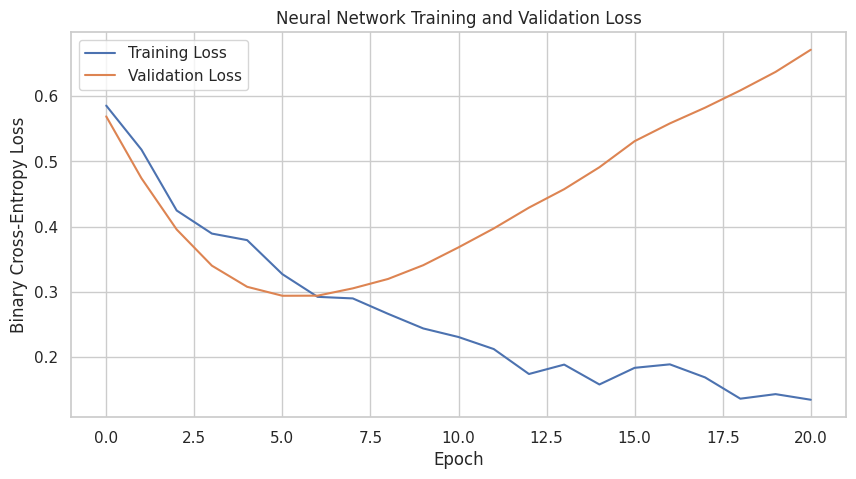

In [242]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(
    "Neural Network Training and Validation Loss"
)

plt.legend()
plt.show()

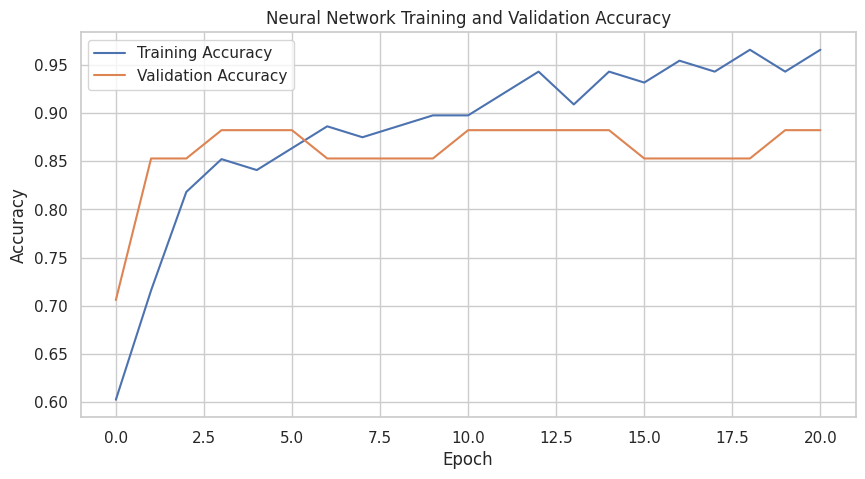

In [243]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Neural Network Training and Validation Accuracy"
)

plt.legend()
plt.show()

In [244]:
print(
    "Training epochs completed:",
    len(history.history["loss"])
)

print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

Training epochs completed: 21
Best validation loss: 0.2935484051704407


In [245]:
y_prob = model.predict(
    X_test_final,
    verbose=0
).ravel()

print("Predicted probabilities:")
print(y_prob)

Predicted probabilities:
[0.05851046 0.59243107 0.03791621 0.5601194  0.25397378 0.12261352
 0.0811218  0.9564645  0.02772642 0.03548923 0.9491448  0.24202567
 0.82094795 0.03940511 0.09511197 0.60528237 0.21617582 0.05087279
 0.98848    0.9737892  0.12407028 0.02111722 0.09680913 0.11737466
 0.9650778  0.5774132  0.15230618 0.02784203 0.04264989 0.03584043
 0.32801896 0.9685485  0.06910238 0.99157006]


In [246]:
y_pred = (
    y_prob >= 0.5
).astype(int)

In [247]:
print("Actual:")
print(y_test_final)

print("\nPredicted:")
print(y_pred)

Actual:
[0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1]

Predicted:
[0 1 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1]


In [248]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    y_test_final,
    y_pred
)

precision = precision_score(
    y_test_final,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test_final,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test_final,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test_final,
    y_prob
)

print("=" * 50)
print("FINAL NEURAL NETWORK TEST RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

FINAL NEURAL NETWORK TEST RESULTS
Accuracy : 0.8529
Precision: 0.5833
Recall   : 1.0000
F1 Score : 0.7368
ROC-AUC  : 0.9841


In [249]:
cm = confusion_matrix(
    y_test_final,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[22  5]
 [ 0  7]]


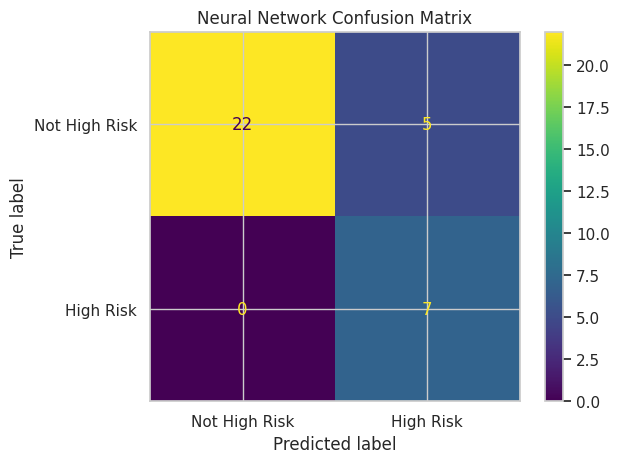

In [250]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not High Risk",
        "High Risk"
    ]
)

disp.plot()

plt.title(
    "Neural Network Confusion Matrix"
)

plt.show()

In [251]:
print(
    classification_report(
        y_test_final,
        y_pred,
        target_names=[
            "Not High Risk",
            "High Risk"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Not High Risk       1.00      0.81      0.90        27
    High Risk       0.58      1.00      0.74         7

     accuracy                           0.85        34
    macro avg       0.79      0.91      0.82        34
 weighted avg       0.91      0.85      0.86        34



In [252]:
test_results = test_df[
    [
        "Station",
        "Year",
        "Total",
        "Fatal",
        "Fatal_Rate",
        "Previous_Year_Accidents",
        "Accident_Change_Percent",
        "Rolling_2Year_Avg",
        "Future_High_Risk"
    ]
].copy()

In [253]:
test_results["Predicted_Probability"] = y_prob

test_results["Predicted_High_Risk"] = y_pred

In [254]:
test_results = test_results.sort_values(
    "Predicted_Probability",
    ascending=False
)

In [255]:
display(test_results)

,Station,Year,Total,Fatal,Fatal_Rate,Previous_Year_Accidents,Accident_Change_Percent,Rolling_2Year_Avg,Future_High_Risk,Predicted_Probability,Predicted_High_Risk
316,Yelahanka,2023,236,58,0.245763,204.0,15.686275,188.0,1,0.991570,1
186,Kamakshipalya,2023,241,40,0.165975,200.0,20.500000,178.5,1,0.988480,1
193,Kengeri,2023,279,58,0.207885,121.0,130.578512,114.0,1,0.973789,1
295,Whitefield,2023,223,43,0.192825,166.0,34.337349,128.5,1,0.968548,1
230,Peenya,2023,192,32,0.166667,178.0,7.865169,151.5,0,0.965078,1
71,Chikkajala,2023,137,36,0.262774,174.0,-21.264368,181.5,1,0.956465,1
97,Electronic City,2023,196,38,0.193878,139.0,41.007194,134.0,1,0.949145,1
118,Hebbal,2023,144,24,0.166667,101.0,42.574257,108.0,1,0.820948,1
150,Jalahalli,2023,102,28,0.274510,80.0,27.500000,85.0,0,0.605282,1
12,Airport,2023,97,17,0.175258,83.0,16.867470,113.0,0,0.592431,1


phase 8

In [256]:
from sklearn.metrics import roc_auc_score

def model_auc(X, y):
    probabilities = model.predict(
        X,
        verbose=0
    ).ravel()

    return roc_auc_score(
        y,
        probabilities
    )

In [257]:
baseline_auc = model_auc(
    X_test_final,
    y_test_final
)

print(
    "Baseline ROC-AUC:",
    round(baseline_auc, 4)
)

Baseline ROC-AUC: 0.9841


In [258]:
numeric_feature_names = feature_columns

station_feature_names = (
    encoder.get_feature_names_out(
        ["Station"]
    ).tolist()
)

all_feature_names = (
    numeric_feature_names +
    station_feature_names
)

print(
    "Total feature names:",
    len(all_feature_names)
)

Total feature names: 58


In [259]:
from sklearn.inspection import permutation_importance

In [260]:
baseline_auc = model_auc(
    X_test_final,
    y_test_final
)

importance_results = []

rng = np.random.default_rng(42)

for i, feature_name in enumerate(
    all_feature_names
):

    drops = []

    for _ in range(20):

        X_permuted = X_test_final.copy()

        shuffled_values = (
            X_permuted[:, i].copy()
        )

        rng.shuffle(
            shuffled_values
        )

        X_permuted[:, i] = (
            shuffled_values
        )

        permuted_auc = model_auc(
            X_permuted,
            y_test_final
        )

        drops.append(
            baseline_auc - permuted_auc
        )

    importance_results.append({
        "Feature": feature_name,
        "Importance": np.mean(drops),
        "Std": np.std(drops)
    })

importance_df = (
    pd.DataFrame(importance_results)
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_df.head(20)
)

,Feature,Importance,Std
0,Fatal,0.007937,0.005674
1,Non-Fatal,0.007143,0.009206
2,Rolling_3Year_Avg,0.003439,0.006322
3,Accident_Change,0.002381,0.005150
4,Previous_NonFatal_Rate,0.002116,0.003085
5,Fatal_Rate,0.001323,0.002291
6,Previous_Year_Fatal,0.001058,0.002116
7,Rolling_2Year_Avg,0.000265,0.001153
8,Station_Airport,0.000265,0.001153
9,Station_Banashankari,0.000265,0.001153


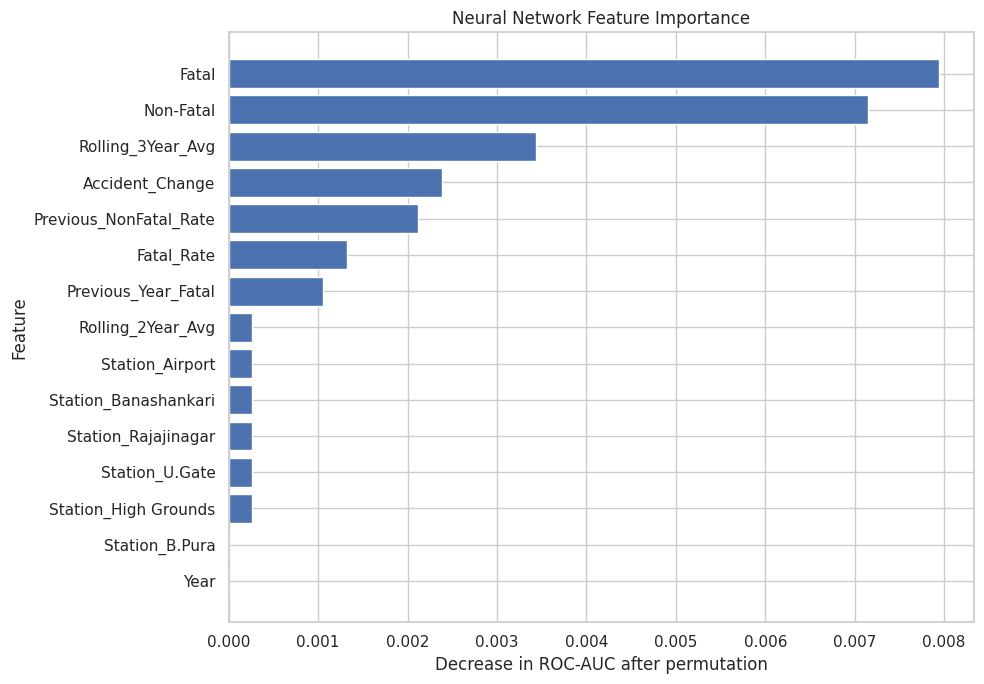

In [261]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel(
    "Decrease in ROC-AUC after permutation"
)

plt.ylabel("Feature")

plt.title(
    "Neural Network Feature Importance"
)

plt.tight_layout()

plt.show()

In [262]:
importance_df.to_csv(
    "bengaluru_nn_feature_importance.csv",
    index=False
)

print(
    "Feature importance saved."
)

Feature importance saved.


In [263]:
warning_table = test_results[
    [
        "Station",
        "Year",
        "Total",
        "Fatal",
        "Fatal_Rate",
        "Previous_Year_Accidents",
        "Accident_Change_Percent",
        "Rolling_2Year_Avg",
        "Future_High_Risk",
        "Predicted_Probability",
        "Predicted_High_Risk"
    ]
].copy()

In [264]:
def risk_label(probability):

    if probability >= 0.70:
        return "HIGH"
    elif probability >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"

warning_table["Predicted_Risk_Level"] = (
    warning_table[
        "Predicted_Probability"
    ].apply(risk_label)
)

In [265]:
display(
    warning_table[
        [
            "Station",
            "Predicted_Probability",
            "Predicted_Risk_Level",
            "Future_High_Risk",
            "Total",
            "Fatal",
            "Fatal_Rate",
            "Previous_Year_Accidents",
            "Accident_Change_Percent",
            "Rolling_2Year_Avg"
        ]
    ]
)

,Station,Predicted_Probability,Predicted_Risk_Level,Future_High_Risk,Total,Fatal,Fatal_Rate,Previous_Year_Accidents,Accident_Change_Percent,Rolling_2Year_Avg
316,Yelahanka,0.991570,HIGH,1,236,58,0.245763,204.0,15.686275,188.0
186,Kamakshipalya,0.988480,HIGH,1,241,40,0.165975,200.0,20.500000,178.5
193,Kengeri,0.973789,HIGH,1,279,58,0.207885,121.0,130.578512,114.0
295,Whitefield,0.968548,HIGH,1,223,43,0.192825,166.0,34.337349,128.5
230,Peenya,0.965078,HIGH,0,192,32,0.166667,178.0,7.865169,151.5
71,Chikkajala,0.956465,HIGH,1,137,36,0.262774,174.0,-21.264368,181.5
97,Electronic City,0.949145,HIGH,1,196,38,0.193878,139.0,41.007194,134.0
118,Hebbal,0.820948,HIGH,1,144,24,0.166667,101.0,42.574257,108.0
150,Jalahalli,0.605282,MEDIUM,0,102,28,0.274510,80.0,27.500000,85.0
12,Airport,0.592431,MEDIUM,0,97,17,0.175258,83.0,16.867470,113.0


phase 9

In [270]:
final_warning_table = test_df[
    [
        "Station",
        "Year",
        "Total",
        "Fatal",
        "Non-Fatal",
        "Fatal_Rate",
        "Previous_Year_Accidents",
        "Previous_Year_Fatal",
        "Previous_NonFatal_Rate",
        "Accident_Change",
        "Accident_Change_Percent",
        "Rolling_2Year_Avg",
        "Rolling_3Year_Avg",
        "Future_High_Risk"
    ]
].copy()

# Add neural network predictions
final_warning_table["Predicted_Probability"] = y_prob

final_warning_table["Predicted_High_Risk"] = y_pred

print("Columns available:")
print(final_warning_table.columns.tolist())

print("\nShape:")
print(final_warning_table.shape)

Columns available:
['Station', 'Year', 'Total', 'Fatal', 'Non-Fatal', 'Fatal_Rate', 'Previous_Year_Accidents', 'Previous_Year_Fatal', 'Previous_NonFatal_Rate', 'Accident_Change', 'Accident_Change_Percent', 'Rolling_2Year_Avg', 'Rolling_3Year_Avg', 'Future_High_Risk', 'Predicted_Probability', 'Predicted_High_Risk']

Shape:
(34, 16)


In [271]:
def get_risk_level(prob):

    if prob >= 0.70:
        return "HIGH"

    elif prob >= 0.40:
        return "MEDIUM"

    else:
        return "LOW"


final_warning_table["Risk_Level"] = (
    final_warning_table[
        "Predicted_Probability"
    ].apply(get_risk_level)
)

In [272]:
def generate_reasons(row):

    reasons = []

    # High fatal crash count
    if row["Fatal"] >= 30:
        reasons.append(
            "High number of fatal crashes"
        )

    # High non-fatal crash count
    if row["Non-Fatal"] >= 100:
        reasons.append(
            "High non-fatal crash frequency"
        )

    # Increasing accident trend
    if row["Accident_Change_Percent"] >= 20:
        reasons.append(
            "Strong increase in accidents"
        )

    # High recent accident level
    if row["Rolling_2Year_Avg"] >= 100:
        reasons.append(
            "High recent accident average"
        )

    # High fatal rate
    if row["Fatal_Rate"] >= 0.20:
        reasons.append(
            "High fatal-crash rate"
        )

    # Previous fatal crashes
    if row["Previous_Year_Fatal"] >= 30:
        reasons.append(
            "High fatal-crash history"
        )

    # If no specific indicator crosses our thresholds
    if len(reasons) == 0:
        reasons.append(
            "Historical accident pattern indicates elevated risk"
        )

    return reasons

In [273]:
final_warning_table["Risk_Indicators"] = (
    final_warning_table.apply(
        generate_reasons,
        axis=1
    )
)

print("Risk explanations generated successfully.")

Risk explanations generated successfully.


In [274]:
high_risk_predictions = (
    final_warning_table[
        final_warning_table[
            "Predicted_High_Risk"
        ] == 1
    ]
    .sort_values(
        "Predicted_Probability",
        ascending=False
    )
)

display(
    high_risk_predictions[
        [
            "Station",
            "Predicted_Probability",
            "Risk_Level",
            "Total",
            "Fatal",
            "Non-Fatal",
            "Fatal_Rate",
            "Accident_Change_Percent",
            "Rolling_2Year_Avg",
            "Risk_Indicators"
        ]
    ]
)

,Station,Predicted_Probability,Risk_Level,Total,Fatal,Non-Fatal,Fatal_Rate,Accident_Change_Percent,Rolling_2Year_Avg,Risk_Indicators
316,Yelahanka,0.991570,HIGH,236,58,178,0.245763,15.686275,188.0,"[High number of fatal crashes, High non-fatal ..."
186,Kamakshipalya,0.988480,HIGH,241,40,201,0.165975,20.500000,178.5,"[High number of fatal crashes, High non-fatal ..."
193,Kengeri,0.973789,HIGH,279,58,221,0.207885,130.578512,114.0,"[High number of fatal crashes, High non-fatal ..."
295,Whitefield,0.968548,HIGH,223,43,180,0.192825,34.337349,128.5,"[High number of fatal crashes, High non-fatal ..."
230,Peenya,0.965078,HIGH,192,32,160,0.166667,7.865169,151.5,"[High number of fatal crashes, High non-fatal ..."
71,Chikkajala,0.956465,HIGH,137,36,101,0.262774,-21.264368,181.5,"[High number of fatal crashes, High non-fatal ..."
97,Electronic City,0.949145,HIGH,196,38,158,0.193878,41.007194,134.0,"[High number of fatal crashes, High non-fatal ..."
118,Hebbal,0.820948,HIGH,144,24,120,0.166667,42.574257,108.0,"[High non-fatal crash frequency, Strong increa..."
150,Jalahalli,0.605282,MEDIUM,102,28,74,0.274510,27.500000,85.0,"[Strong increase in accidents, High fatal-cras..."
12,Airport,0.592431,MEDIUM,97,17,80,0.175258,16.867470,113.0,[High recent accident average]


phase 10

In [275]:
dashboard_df = final_warning_table.copy()

dashboard_df["Predicted_Risk_Percent"] = (
    dashboard_df["Predicted_Probability"] * 100
)

dashboard_df = dashboard_df[
    [
        "Station",
        "Year",
        "Total",
        "Fatal",
        "Non-Fatal",
        "Fatal_Rate",
        "Previous_Year_Accidents",
        "Accident_Change",
        "Accident_Change_Percent",
        "Rolling_2Year_Avg",
        "Rolling_3Year_Avg",
        "Predicted_Risk_Percent",
        "Risk_Level",
        "Future_High_Risk",
        "Predicted_High_Risk",
        "Risk_Indicators"
    ]
]

display(
    dashboard_df.head(15)
)

,Station,Year,Total,Fatal,Non-Fatal,Fatal_Rate,Previous_Year_Accidents,Accident_Change,Accident_Change_Percent,Rolling_2Year_Avg,Rolling_3Year_Avg,Predicted_Risk_Percent,Risk_Level,Future_High_Risk,Predicted_High_Risk,Risk_Indicators
5,Adugodi,2023,63,10,53,0.158730,42.0,21.0,50.000000,30.5,30.000000,5.851046,LOW,0,0,[Strong increase in accidents]
12,Airport,2023,97,17,80,0.175258,83.0,14.0,16.867470,113.0,96.666667,59.243107,MEDIUM,0,1,[High recent accident average]
19,Ashoknagar,2023,38,6,32,0.157895,35.0,3.0,8.571429,38.5,39.000000,3.791620,LOW,0,0,[Historical accident pattern indicates elevate...
31,Banasawadi,2023,91,14,77,0.153846,116.0,-25.0,-21.551724,107.5,102.000000,56.011940,MEDIUM,0,1,[High recent accident average]
38,Banashankari,2023,90,15,75,0.166667,67.0,23.0,34.328358,68.5,68.000000,25.397379,LOW,0,0,[Strong increase in accidents]
45,Basavanagudi,2023,102,3,99,0.029412,85.0,17.0,20.000000,66.5,61.666667,12.261352,LOW,0,0,[Strong increase in accidents]
63,Chickpet,2023,46,9,37,0.195652,40.0,6.0,15.000000,35.0,35.333333,8.112181,LOW,0,0,[Historical accident pattern indicates elevate...
71,Chikkajala,2023,137,36,101,0.262774,174.0,-37.0,-21.264368,181.5,181.666667,95.646454,HIGH,1,1,"[High number of fatal crashes, High non-fatal ..."
78,City Market,2023,32,9,23,0.281250,18.0,14.0,77.777778,12.5,11.333333,2.772642,LOW,0,0,"[Strong increase in accidents, High fatal-cras..."
85,Cubbon Park,2023,56,2,54,0.035714,37.0,19.0,51.351351,37.5,33.666667,3.548923,LOW,0,0,[Strong increase in accidents]


In [276]:
dashboard_df.to_csv(
    "bengaluru_accident_early_warning_results.csv",
    index=False
)

print(
    "Final early-warning dataset saved."
)

Final early-warning dataset saved.


In [277]:
high_risk_report = (
    dashboard_df[
        dashboard_df["Predicted_High_Risk"] == 1
    ]
    .sort_values(
        "Predicted_Risk_Percent",
        ascending=False
    )
)

display(
    high_risk_report[
        [
            "Station",
            "Predicted_Risk_Percent",
            "Risk_Level",
            "Total",
            "Fatal",
            "Accident_Change_Percent",
            "Risk_Indicators"
        ]
    ]
)

,Station,Predicted_Risk_Percent,Risk_Level,Total,Fatal,Accident_Change_Percent,Risk_Indicators
316,Yelahanka,99.157005,HIGH,236,58,15.686275,"[High number of fatal crashes, High non-fatal ..."
186,Kamakshipalya,98.848000,HIGH,241,40,20.500000,"[High number of fatal crashes, High non-fatal ..."
193,Kengeri,97.378922,HIGH,279,58,130.578512,"[High number of fatal crashes, High non-fatal ..."
295,Whitefield,96.854851,HIGH,223,43,34.337349,"[High number of fatal crashes, High non-fatal ..."
230,Peenya,96.507782,HIGH,192,32,7.865169,"[High number of fatal crashes, High non-fatal ..."
71,Chikkajala,95.646454,HIGH,137,36,-21.264368,"[High number of fatal crashes, High non-fatal ..."
97,Electronic City,94.914474,HIGH,196,38,41.007194,"[High number of fatal crashes, High non-fatal ..."
118,Hebbal,82.094795,HIGH,144,24,42.574257,"[High non-fatal crash frequency, Strong increa..."
150,Jalahalli,60.528236,MEDIUM,102,28,27.500000,"[Strong increase in accidents, High fatal-cras..."
12,Airport,59.243107,MEDIUM,97,17,16.867470,[High recent accident average]


In [278]:
high_risk_report.to_csv(
    "bengaluru_high_risk_warning_report.csv",
    index=False
)

print(
    "High-risk warning report saved."
)

High-risk warning report saved.


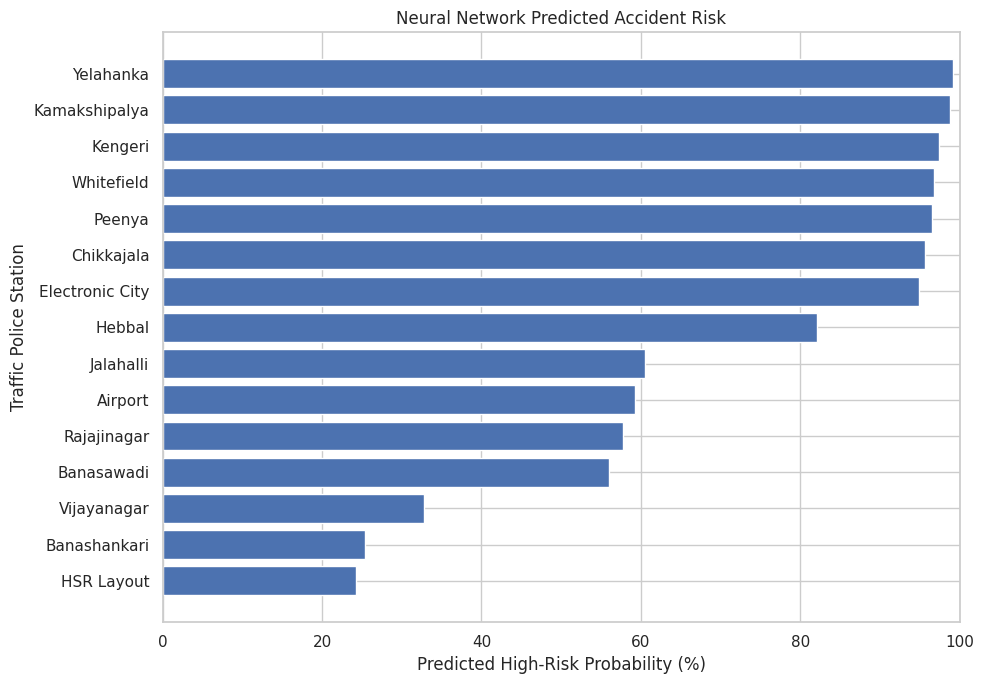

In [279]:
top_predictions = (
    dashboard_df
    .sort_values(
        "Predicted_Risk_Percent",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_predictions["Station"][::-1],
    top_predictions["Predicted_Risk_Percent"][::-1]
)

plt.xlabel(
    "Predicted High-Risk Probability (%)"
)

plt.ylabel("Traffic Police Station")

plt.title(
    "Neural Network Predicted Accident Risk"
)

plt.xlim(0, 100)

plt.tight_layout()

plt.show()

In [280]:
!pip install folium -q

In [281]:
import folium
import pandas as pd
import numpy as np

In [282]:
print("map_dataset exists:", "map_dataset" in globals())

if "map_dataset" in globals():
    print("Shape:", map_dataset.shape)
    print("Columns:")
    print(map_dataset.columns.tolist())

map_dataset exists: True
Shape: (36, 11)
Columns:
['Hotspot_Rank', 'Station', 'Latitude', 'Longitude', 'Total_Accidents', 'Fatal_Crashes', 'Fatal_Rate', 'Years_In_Top10', 'Recent_Trend_Percent', 'Hotspot_Score_100', 'Hotspot_Category']


In [283]:
map_coords = map_dataset.copy()

print(map_coords.head())

   Hotspot_Rank          Station   Latitude  Longitude  Total_Accidents  \
0             1        Yelahanka  13.094937  77.594081             1530   
1             2       Whitefield  12.994247  77.757161             1148   
2             3  Electronic City  12.839192  77.661783             1127   
3             4    Kamakshipalya  12.982167  77.532701             1329   
5             6        K.R.Puram  13.007969  77.693836             1005   

   Fatal_Crashes  Fatal_Rate  Years_In_Top10  Recent_Trend_Percent  \
0            345    0.225490               7             13.593156   
1            243    0.211672               6             39.945652   
2            223    0.197870               7             24.169987   
3            211    0.158766               7              1.959746   
5            195    0.194030               4                   NaN   

   Hotspot_Score_100 Hotspot_Category  
0          72.651503             HIGH  
1          62.511916             HIGH  
2       

In [286]:
print("map_coords exists:", "map_coords" in globals())

if "map_coords" in globals():
    print(map_coords.columns.tolist())
    display(map_coords.head())

map_coords exists: True
['Hotspot_Rank', 'Station', 'Latitude', 'Longitude', 'Total_Accidents', 'Fatal_Crashes', 'Fatal_Rate', 'Years_In_Top10', 'Recent_Trend_Percent', 'Hotspot_Score_100', 'Hotspot_Category']


,Hotspot_Rank,Station,Latitude,Longitude,Total_Accidents,Fatal_Crashes,Fatal_Rate,Years_In_Top10,Recent_Trend_Percent,Hotspot_Score_100,Hotspot_Category
0,1,Yelahanka,13.094937,77.594081,1530,345,0.225490,7,13.593156,72.651503,HIGH
1,2,Whitefield,12.994247,77.757161,1148,243,0.211672,6,39.945652,62.511916,HIGH
2,3,Electronic City,12.839192,77.661783,1127,223,0.197870,7,24.169987,62.024174,HIGH
3,4,Kamakshipalya,12.982167,77.532701,1329,211,0.158766,7,1.959746,61.143759,HIGH
5,6,K.R.Puram,13.007969,77.693836,1005,195,0.194030,4,NaN,58.472579,HIGH


In [288]:
import os

print(os.path.exists("bengaluru_traffic_stations.kml"))
print(os.listdir())

True
['.config', 'bengaluru_nn_feature_importance.csv', 'yearly_accident_summary.csv', 'bengaluru_accident_early_warning_results.csv', 'master_bengaluru_accidents_2018_2024 (1).csv', 'station_accident_summary.csv', 'bengaluru_accident_hotspot_map.html', 'bengaluru_hotspot_map_data.csv', 'drive', 'bengaluru_accident_hotspot_scores (1).csv', 'bengaluru_high_risk_warning_report.csv', 'master_bengaluru_accidents_2018_2024.csv', 'bengaluru_accident_hotspot_scores.csv', 'bengaluru_traffic_stations.kml', 'station_hotspot_consistency.csv', 'sample_data']


In [291]:
import xml.etree.ElementTree as ET
import pandas as pd

kml_file = "bengaluru_traffic_stations.kml"

tree = ET.parse(kml_file)
root = tree.getroot()

ns = {
    "kml": "http://www.opengis.net/kml/2.2"
}

records = []

for placemark in root.findall(".//kml:Placemark", ns):

    station_name = None

    # ------------------------------------------------
    # 1. Look inside SimpleData
    # ------------------------------------------------

    simple_data = placemark.findall(
        ".//kml:SimpleData",
        ns
    )

    for item in simple_data:

        field_name = item.get("name")

        if field_name == "TRF_POL_STAName":

            if item.text:
                station_name = item.text.strip()

    # ------------------------------------------------
    # 2. If not found, try Placemark name
    # ------------------------------------------------

    if station_name is None:

        name_element = placemark.find(
            "kml:name",
            ns
        )

        if (
            name_element is not None
            and name_element.text
        ):
            station_name = name_element.text.strip()

    # ------------------------------------------------
    # 3. Extract coordinates
    # ------------------------------------------------

    coord_element = placemark.find(
        ".//kml:coordinates",
        ns
    )

    if coord_element is None:
        continue

    if not coord_element.text:
        continue

    coord_text = coord_element.text.strip()

    first_coord = coord_text.split()[0]

    parts = first_coord.split(",")

    if len(parts) < 2:
        continue

    try:

        longitude = float(parts[0])
        latitude = float(parts[1])

    except ValueError:

        continue

    records.append({
        "Station": station_name,
        "Latitude": latitude,
        "Longitude": longitude
    })


map_coords = pd.DataFrame(records)

print(
    "KML stations loaded:",
    len(map_coords)
)

display(
    map_coords.head(15)
)

KML stations loaded: 43


,Station,Latitude,Longitude
0,"Traffic Police Station, Adugodi",12.941522,77.608589
1,"Traffic Police Station, Airport Bengaluru",12.955353,77.682508
2,"Traffic Police Station, Ashoknagar",12.971633,77.610331
3,"Traffic Police Station, Banasawadi",13.019503,77.640219
4,"Traffic Police Station, Cubbonpark",12.975933,77.597850
5,"Traffic Police Station, Electronic City",12.839192,77.661783
6,"Traffic Police Station, Halasur Gate",12.966569,77.587197
7,"Traffic Police Station, Halasur",12.974700,77.625311
8,"Traffic Police Station, High Grounds",12.984711,77.583047
9,"Traffic Police Station, Hulimavu",12.856511,77.588994


In [292]:
map_coords["Station"] = (
    map_coords["Station"]
    .astype(str)
    .str.replace(
        "Traffic Police Station, ",
        "",
        regex=False
    )
    .str.strip()
)

display(map_coords.head(15))

,Station,Latitude,Longitude
0,Adugodi,12.941522,77.608589
1,Airport Bengaluru,12.955353,77.682508
2,Ashoknagar,12.971633,77.610331
3,Banasawadi,13.019503,77.640219
4,Cubbonpark,12.975933,77.597850
5,Electronic City,12.839192,77.661783
6,Halasur Gate,12.966569,77.587197
7,Halasur,12.974700,77.625311
8,High Grounds,12.984711,77.583047
9,Hulimavu,12.856511,77.588994


In [293]:
def normalize_station_name(name):

    name = str(name).strip().lower()

    replacements = {
        "chikjala": "chikkajala",
        "chikkajala": "chikkajala",

        "k.r.pura": "k.r.puram",
        "k r pura": "k.r.puram",
        "k.r.puram": "k.r.puram",

        "yalahanka": "yelahanka",
        "yelahanka": "yelahanka",

        "ashokanagar": "ashoknagar",
        "ashoknagar": "ashoknagar",

        "halasooru": "halasur",
        "halasur": "halasur",

        "malleswaram": "malleshwaram",
        "malleshwaram": "malleshwaram",

        "h.grounds": "high grounds",
        "high grounds": "high grounds",

        "w.garden": "wilsongarden",
        "wilsongarden": "wilsongarden",

        "airport bengaluru": "international airport",
        "international airport": "international airport"
    }

    return replacements.get(
        name,
        name
    )


map_coords["Station_Key"] = (
    map_coords["Station"]
    .apply(normalize_station_name)
)

dashboard_df["Station_Key"] = (
    dashboard_df["Station"]
    .apply(normalize_station_name)
)

In [294]:
coords_clean = map_coords[
    [
        "Station",
        "Station_Key",
        "Latitude",
        "Longitude"
    ]
].drop_duplicates(
    subset="Station_Key"
)

pred_clean = dashboard_df[
    [
        "Station",
        "Station_Key",
        "Predicted_Risk_Percent",
        "Risk_Level",
        "Total",
        "Fatal",
        "Non-Fatal",
        "Fatal_Rate",
        "Accident_Change_Percent",
        "Rolling_2Year_Avg",
        "Risk_Indicators"
    ]
].drop_duplicates(
    subset="Station_Key"
)

map_final = pd.merge(
    coords_clean,
    pred_clean,
    on="Station_Key",
    how="inner",
    suffixes=(
        "_Coordinates",
        "_Prediction"
    )
)

print(
    "KML stations:",
    len(coords_clean)
)

print(
    "Prediction stations:",
    len(pred_clean)
)

print(
    "Final mapped stations:",
    len(map_final)
)

display(
    map_final[
        [
            "Station_Coordinates",
            "Latitude",
            "Longitude",
            "Predicted_Risk_Percent",
            "Risk_Level"
        ]
    ]
)

KML stations: 43
Prediction stations: 34
Final mapped stations: 28


,Station_Coordinates,Latitude,Longitude,Predicted_Risk_Percent,Risk_Level
0,Adugodi,12.941522,77.608589,5.851046,LOW
1,Ashoknagar,12.971633,77.610331,3.791620,LOW
2,Banasawadi,13.019503,77.640219,56.011940,MEDIUM
3,Electronic City,12.839192,77.661783,94.914474,HIGH
4,High Grounds,12.984711,77.583047,3.940511,LOW
5,Madivala,12.920992,77.620725,12.407028,LOW
6,Mico Layout,12.913278,77.600061,11.737466,LOW
7,Shivajinagar,12.987919,77.603422,2.784203,LOW
8,Whitefield,12.994247,77.757161,96.854851,HIGH
9,Wilsongarden,12.950144,77.595617,6.910238,LOW


In [295]:
import folium

bengaluru_map = folium.Map(
    location=[12.9716, 77.5946],
    zoom_start=11,
    tiles="OpenStreetMap"
)

risk_colors = {
    "HIGH": "red",
    "MEDIUM": "orange",
    "LOW": "green"
}

In [296]:
for _, row in map_final.iterrows():

    station = row["Station_Coordinates"]
    risk = row["Risk_Level"]

    probability = row[
        "Predicted_Risk_Percent"
    ]

    indicators = row[
        "Risk_Indicators"
    ]

    if isinstance(indicators, list):

        indicators_text = "<br>• ".join(
            str(x) for x in indicators
        )

    else:

        indicators_text = str(indicators)

    popup_html = f"""
    <div style="width:330px">

        <h3>🚨 {station}</h3>

        <hr>

        <b>Predicted Accident Risk:</b>
        {probability:.2f}%

        <br>

        <b>Risk Level:</b>
        {risk}

        <hr>

        <b>Total Accidents:</b>
        {row["Total"]}

        <br>

        <b>Fatal Crashes:</b>
        {row["Fatal"]}

        <br>

        <b>Non-Fatal Crashes:</b>
        {row["Non-Fatal"]}

        <br>

        <b>Fatal Rate:</b>
        {row["Fatal_Rate"]:.2%}

        <br>

        <b>Accident Change:</b>
        {row["Accident_Change_Percent"]:.2f}%

        <br>

        <b>2-Year Rolling Average:</b>
        {row["Rolling_2Year_Avg"]:.1f}

        <hr>

        <b>Why is this location risky?</b>

        <br><br>

        • {indicators_text}

    </div>
    """

    folium.CircleMarker(
        location=[
            row["Latitude"],
            row["Longitude"]
        ],

        radius=9,

        color=risk_colors.get(
            risk,
            "blue"
        ),

        fill=True,

        fill_color=risk_colors.get(
            risk,
            "blue"
        ),

        fill_opacity=0.75,

        popup=folium.Popup(
            popup_html,
            max_width=360
        ),

        tooltip=(
            f"{station} | "
            f"{risk} | "
            f"{probability:.1f}%"
        )

    ).add_to(
        bengaluru_map
    )

In [297]:
legend_html = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 180px;
z-index: 9999;
background-color: white;
border: 2px solid grey;
padding: 12px;
font-size: 14px;
">

<b>Neural Network Accident Risk</b>

<br><br>

<span style="color:red;font-size:20px;">●</span>
HIGH

<br>

<span style="color:orange;font-size:20px;">●</span>
MEDIUM

<br>

<span style="color:green;font-size:20px;">●</span>
LOW

</div>
"""

bengaluru_map.get_root().html.add_child(
    folium.Element(legend_html)
)

In [298]:
bengaluru_map

In [299]:
bengaluru_map.save(
    "bengaluru_accident_early_warning_map.html"
)

print("FINAL MAP SAVED SUCCESSFULLY")

FINAL MAP SAVED SUCCESSFULLY


In [300]:
from google.colab import files

files.download(
    "bengaluru_accident_early_warning_map.html"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

phase 11

In [302]:
print("X_test type:", type(X_test))

if hasattr(X_test, "columns"):
    print("\nX_test columns:")
    print(X_test.columns.tolist())

    print("\nData types:")
    print(X_test.dtypes)

    print("\nFirst row:")
    display(X_test.head(1))
else:
    print("X_test shape:", X_test.shape)

X_test type: <class 'pandas.core.frame.DataFrame'>

X_test columns:
['Year', 'Total', 'Fatal', 'Non-Fatal', 'Fatal_Rate', 'Previous_Year_Accidents', 'Previous_Year_Fatal', 'Previous_Year_NonFatal', 'Previous_Fatal_Rate', 'Previous_NonFatal_Rate', 'Accident_Change', 'Accident_Change_Percent', 'Rolling_2Year_Avg', 'Rolling_3Year_Avg', 'Station']

Data types:
Year                         int64
Total                        int64
Fatal                        int64
Non-Fatal                    int64
Fatal_Rate                 float64
Previous_Year_Accidents    float64
Previous_Year_Fatal        float64
Previous_Year_NonFatal     float64
Previous_Fatal_Rate        float64
Previous_NonFatal_Rate     float64
Accident_Change            float64
Accident_Change_Percent    float64
Rolling_2Year_Avg          float64
Rolling_3Year_Avg          float64
Station                     object
dtype: object

First row:


,Year,Total,Fatal,Non-Fatal,Fatal_Rate,Previous_Year_Accidents,Previous_Year_Fatal,Previous_Year_NonFatal,Previous_Fatal_Rate,Previous_NonFatal_Rate,Accident_Change,Accident_Change_Percent,Rolling_2Year_Avg,Rolling_3Year_Avg,Station
5,2023,63,10,53,0.15873,42.0,6.0,36.0,0.142857,0.857143,21.0,50.0,30.5,30.0,Adugodi


FINAL TEST DATA CHECK
X_test_final shape: (34, 58)
Model input shape: (None, 58)

FINAL NEURAL NETWORK TEST RESULTS
Accuracy  : 0.8529
Precision : 0.5833
Recall    : 1.0000
F1 Score  : 0.7368
ROC-AUC   : 0.9841

Confusion Matrix:
[[22  5]
 [ 0  7]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      0.81      0.90        27
   High Risk       0.58      1.00      0.74         7

    accuracy                           0.85        34
   macro avg       0.79      0.91      0.82        34
weighted avg       0.91      0.85      0.86        34



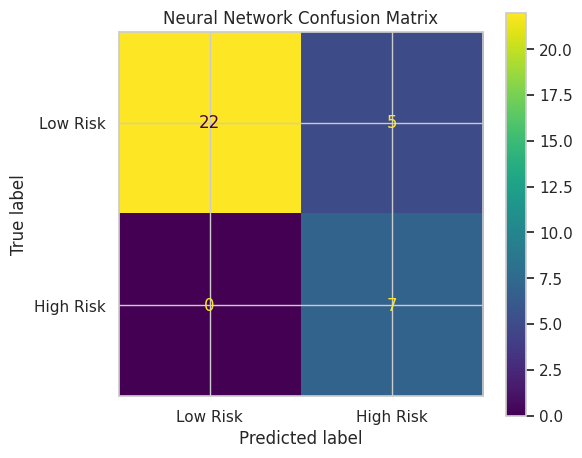

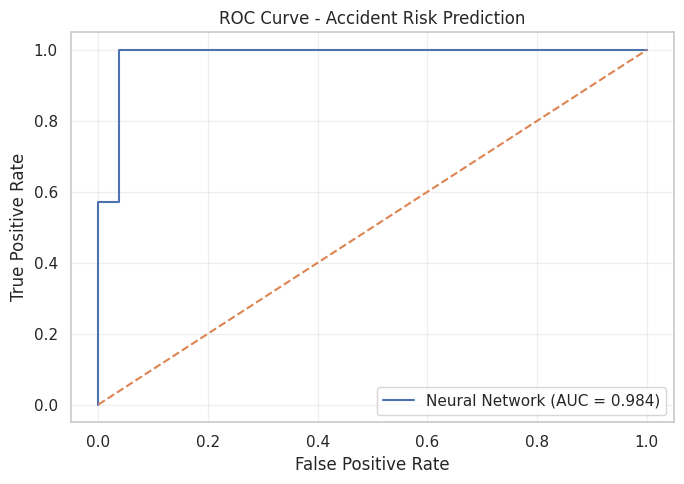

In [304]:
# ============================================================
# PHASE 11 — FINAL NEURAL NETWORK EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# ------------------------------------------------------------
# 1. Use the SAME processed test data used by the model
# ------------------------------------------------------------

X_test_model = X_test_final

print("=" * 60)
print("FINAL TEST DATA CHECK")
print("=" * 60)

print("X_test_final shape:", X_test_final.shape)
print("Model input shape:", model.input_shape)

# ------------------------------------------------------------
# 2. Generate predictions
# ------------------------------------------------------------

y_prob = model.predict(
    X_test_model,
    verbose=0
).ravel()

y_pred = (
    y_prob >= 0.50
).astype(int)

# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# ------------------------------------------------------------
# 4. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL NEURAL NETWORK TEST RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 6. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low Risk",
            "High Risk"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. Confusion Matrix Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Low Risk",
        "High Risk"
    ]
).plot(ax=ax)

ax.set_title(
    "Neural Network Confusion Matrix"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. ROC Curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Neural Network (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Accident Risk Prediction"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

phase 12

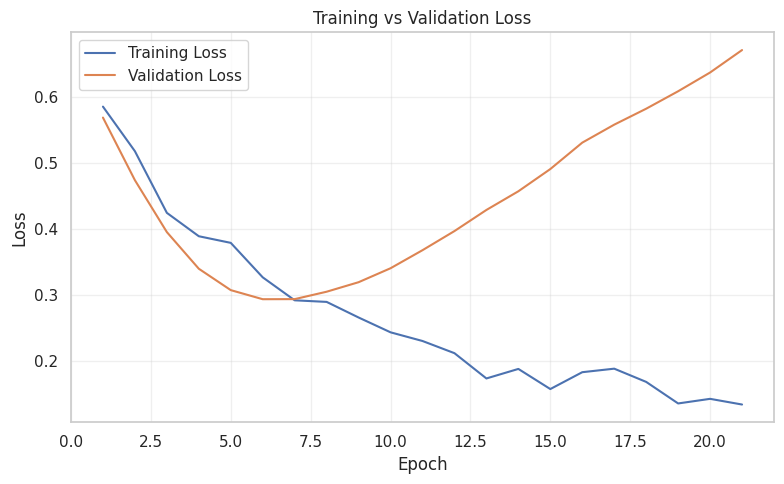

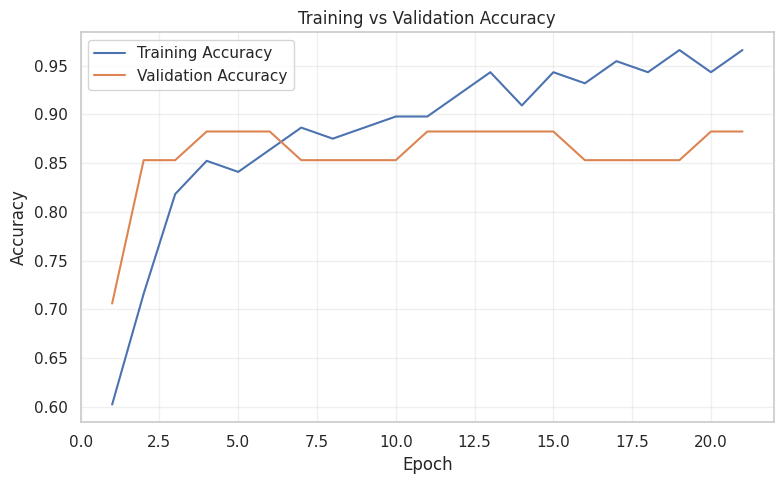

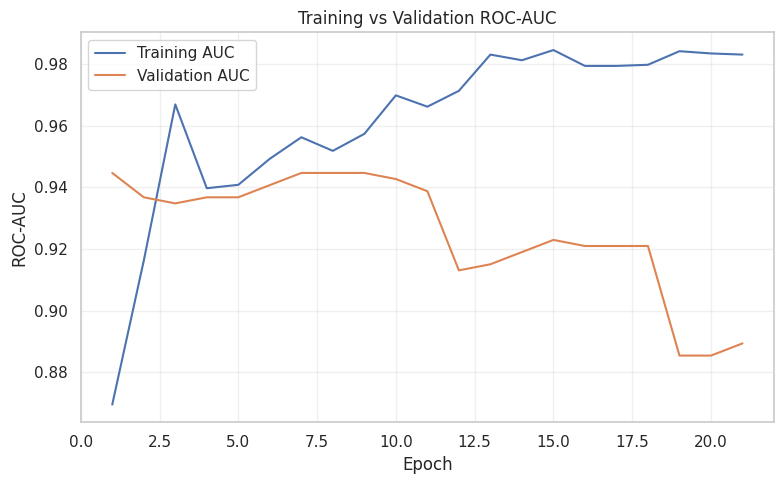

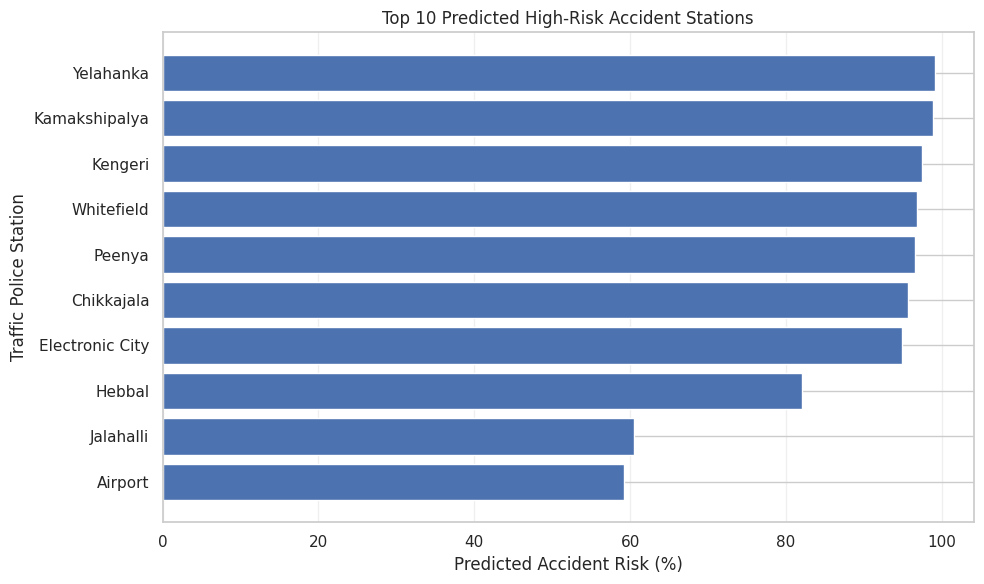

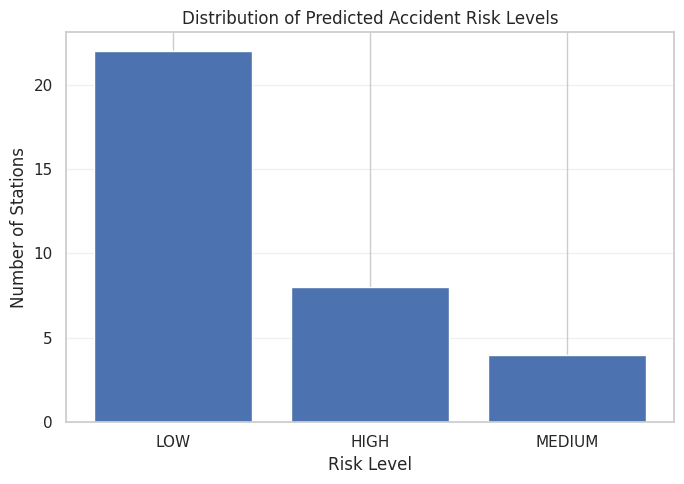

TOP 10 PREDICTED HIGH-RISK STATIONS


,Station,Predicted_Risk_Percent,Risk_Level,Total,Fatal,Fatal_Rate,Accident_Change_Percent,Rolling_2Year_Avg
0,Yelahanka,99.157005,HIGH,236,58,0.245763,15.686275,188.0
1,Kamakshipalya,98.848000,HIGH,241,40,0.165975,20.500000,178.5
2,Kengeri,97.378922,HIGH,279,58,0.207885,130.578512,114.0
3,Whitefield,96.854851,HIGH,223,43,0.192825,34.337349,128.5
4,Peenya,96.507782,HIGH,192,32,0.166667,7.865169,151.5
5,Chikkajala,95.646454,HIGH,137,36,0.262774,-21.264368,181.5
6,Electronic City,94.914474,HIGH,196,38,0.193878,41.007194,134.0
7,Hebbal,82.094795,HIGH,144,24,0.166667,42.574257,108.0
8,Jalahalli,60.528236,MEDIUM,102,28,0.274510,27.500000,85.0
9,Airport,59.243107,MEDIUM,97,17,0.175258,16.867470,113.0


RISK CATEGORY DISTRIBUTION


,Risk Level,Number of Stations
0,LOW,22
1,HIGH,8
2,MEDIUM,4


In [305]:
# ============================================================
# PHASE 12 — FINAL MODEL PERFORMANCE GRAPHS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# GRAPH 1 — TRAINING VS VALIDATION LOSS
# ============================================================

history_dict = history.history

epochs = range(
    1,
    len(history_dict["loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_dict["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_dict["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 2 — TRAINING VS VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_dict["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_dict["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3 — TRAINING VS VALIDATION ROC-AUC
# ============================================================

if "auc" in history_dict and "val_auc" in history_dict:

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_dict["auc"],
        label="Training AUC"
    )

    plt.plot(
        epochs,
        history_dict["val_auc"],
        label="Validation AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")

    plt.title(
        "Training vs Validation ROC-AUC"
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

else:

    print(
        "AUC history is not available."
    )


# ============================================================
# GRAPH 4 — TOP 10 PREDICTED HIGH-RISK STATIONS
# ============================================================

plot_df = dashboard_df.copy()

plot_df = plot_df.sort_values(
    "Predicted_Risk_Percent",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Station"].astype(str),
    plot_df["Predicted_Risk_Percent"]
)

plt.xlabel(
    "Predicted Accident Risk (%)"
)

plt.ylabel(
    "Traffic Police Station"
)

plt.title(
    "Top 10 Predicted High-Risk Accident Stations"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 5 — RISK CATEGORY DISTRIBUTION
# ============================================================

risk_counts = (
    dashboard_df["Risk_Level"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel(
    "Risk Level"
)

plt.ylabel(
    "Number of Stations"
)

plt.title(
    "Distribution of Predicted Accident Risk Levels"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# TOP 10 TABLE
# ============================================================

print("=" * 65)
print("TOP 10 PREDICTED HIGH-RISK STATIONS")
print("=" * 65)

display(
    plot_df[
        [
            "Station",
            "Predicted_Risk_Percent",
            "Risk_Level",
            "Total",
            "Fatal",
            "Fatal_Rate",
            "Accident_Change_Percent",
            "Rolling_2Year_Avg"
        ]
    ].reset_index(drop=True)
)


# ============================================================
# RISK DISTRIBUTION TABLE
# ============================================================

print("=" * 65)
print("RISK CATEGORY DISTRIBUTION")
print("=" * 65)

risk_distribution = (
    dashboard_df["Risk_Level"]
    .value_counts()
    .rename_axis("Risk Level")
    .reset_index(
        name="Number of Stations"
    )
)

display(
    risk_distribution
)

In [306]:
# ============================================================
# PHASE 13 — FINAL PROJECT SUMMARY & EXPORT
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 70)
print("       BENGALURU ROAD ACCIDENT EARLY WARNING SYSTEM")
print("              FINAL PROJECT SUMMARY")
print("=" * 70)


# ============================================================
# 1. FINAL MODEL PERFORMANCE
# ============================================================

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

final_metrics["Percentage"] = (
    final_metrics["Value"] * 100
).round(2)

print("\n" + "=" * 70)
print("1. FINAL NEURAL NETWORK PERFORMANCE")
print("=" * 70)

display(final_metrics)


# ============================================================
# 2. CONFUSION MATRIX VALUES
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

confusion_table = pd.DataFrame(
    cm,
    index=[
        "Actual Low Risk",
        "Actual High Risk"
    ],
    columns=[
        "Predicted Low Risk",
        "Predicted High Risk"
    ]
)

print("\n" + "=" * 70)
print("2. CONFUSION MATRIX")
print("=" * 70)

display(confusion_table)


# ============================================================
# 3. RISK CATEGORY DISTRIBUTION
# ============================================================

risk_distribution = (
    dashboard_df["Risk_Level"]
    .value_counts()
    .reindex(
        ["HIGH", "MEDIUM", "LOW"],
        fill_value=0
    )
    .rename_axis("Risk Level")
    .reset_index(
        name="Number of Stations"
    )
)

risk_distribution["Percentage"] = (
    risk_distribution["Number of Stations"]
    / risk_distribution["Number of Stations"].sum()
    * 100
).round(2)

print("\n" + "=" * 70)
print("3. RISK CATEGORY DISTRIBUTION")
print("=" * 70)

display(risk_distribution)


# ============================================================
# 4. TOP 10 HIGH-RISK STATIONS
# ============================================================

top_10 = (
    dashboard_df
    .sort_values(
        "Predicted_Risk_Percent",
        ascending=False
    )
    .head(10)
    .copy()
)

top_10["Rank"] = range(
    1,
    len(top_10) + 1
)

top_10 = top_10[
    [
        "Rank",
        "Station",
        "Predicted_Risk_Percent",
        "Risk_Level",
        "Total",
        "Fatal",
        "Non-Fatal",
        "Fatal_Rate",
        "Accident_Change_Percent",
        "Rolling_2Year_Avg",
        "Risk_Indicators"
    ]
]

print("\n" + "=" * 70)
print("4. TOP 10 PREDICTED HIGH-RISK STATIONS")
print("=" * 70)

display(top_10)


# ============================================================
# 5. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("5. IMPORTANT PREDICTIVE FEATURES")
print("=" * 70)

# Check whether feature importance dataframe exists
if "feature_importance_df" in globals():

    display(
        feature_importance_df.head(10)
    )

elif "feature_importance" in globals():

    display(
        feature_importance.head(10)
    )

else:

    print(
        "Feature importance dataframe was not found."
    )

    print(
        "Use the feature-importance table generated earlier."
    )


# ============================================================
# 6. PROJECT STATISTICS
# ============================================================

total_stations = (
    dashboard_df["Station"]
    .nunique()
)

high_risk_count = (
    dashboard_df["Risk_Level"]
    .eq("HIGH")
    .sum()
)

medium_risk_count = (
    dashboard_df["Risk_Level"]
    .eq("MEDIUM")
    .sum()
)

low_risk_count = (
    dashboard_df["Risk_Level"]
    .eq("LOW")
    .sum()
)

map_station_count = (
    len(map_final)
    if "map_final" in globals()
    else 0
)

print("\n" + "=" * 70)
print("6. OVERALL PROJECT STATISTICS")
print("=" * 70)

print(
    f"Total accident-data stations : {total_stations}"
)

print(
    f"High-risk stations           : {high_risk_count}"
)

print(
    f"Medium-risk stations         : {medium_risk_count}"
)

print(
    f"Low-risk stations            : {low_risk_count}"
)

print(
    f"Stations shown on map        : {map_station_count}"
)

print(
    f"Test accuracy                : {accuracy:.2%}"
)

print(
    f"Test precision               : {precision:.2%}"
)

print(
    f"Test recall                  : {recall:.2%}"
)

print(
    f"Test F1 score                : {f1:.2%}"
)

print(
    f"Test ROC-AUC                 : {roc_auc:.4f}"
)


# ============================================================
# 7. FINAL PROJECT CONCLUSION TEXT
# ============================================================

print("\n" + "=" * 70)
print("7. PROJECT CONCLUSION")
print("=" * 70)

conclusion = f"""
The developed Bengaluru Road Accident Early Warning System
uses a neural network to identify locations with elevated
future accident risk based on historical accident patterns
and engineered temporal and severity-related features.

The neural network achieved an accuracy of {accuracy:.2%},
precision of {precision:.2%}, recall of {recall:.2%},
F1 score of {f1:.2%}, and ROC-AUC of {roc_auc:.4f}
on the test dataset.

The model achieved 100% recall in the evaluated test set,
meaning that all actual high-risk cases in the test set
were identified by the model. This is particularly useful
for an early-warning application, where identifying
potentially dangerous locations is more important than
avoiding every false warning.

The system also provides risk indicators that help explain
why a station is considered risky, including high fatal
crash counts, high non-fatal crash frequency, elevated
fatal-crash rates, recent accident averages, and increasing
accident trends.

Finally, the predictions were integrated with verified
geographical coordinates to produce an interactive
Bengaluru accident-risk map. The map allows users to
identify high-, medium-, and low-risk locations and inspect
the factors contributing to the predicted risk.

Therefore, the proposed system combines historical hotspot
analysis, neural-network-based prediction, explainable
risk indicators, and geographic visualization into an
AI-based road accident early-warning framework for Bengaluru.
"""

print(conclusion)


# ============================================================
# 8. EXPORT FINAL TABLES
# ============================================================

# Final metrics
final_metrics.to_csv(
    "FINAL_NN_MODEL_METRICS.csv",
    index=False
)

# Confusion matrix
confusion_table.to_csv(
    "FINAL_CONFUSION_MATRIX.csv"
)

# Risk distribution
risk_distribution.to_csv(
    "FINAL_RISK_DISTRIBUTION.csv",
    index=False
)

# Top 10 stations
top_10.to_csv(
    "FINAL_TOP_10_HIGH_RISK_STATIONS.csv",
    index=False
)

# Complete prediction dashboard
dashboard_df.to_csv(
    "FINAL_ACCIDENT_RISK_PREDICTIONS.csv",
    index=False
)

# Map dataset
if "map_final" in globals():

    map_final.to_csv(
        "FINAL_MAP_DATASET.csv",
        index=False
    )

print("\n" + "=" * 70)
print("FINAL FILES CREATED")
print("=" * 70)

files_created = [
    "FINAL_NN_MODEL_METRICS.csv",
    "FINAL_CONFUSION_MATRIX.csv",
    "FINAL_RISK_DISTRIBUTION.csv",
    "FINAL_TOP_10_HIGH_RISK_STATIONS.csv",
    "FINAL_ACCIDENT_RISK_PREDICTIONS.csv"
]

if "map_final" in globals():
    files_created.append(
        "FINAL_MAP_DATASET.csv"
    )

for file in files_created:
    print("✓", file)


# ============================================================
# 9. CHECK FINAL MAP
# ============================================================

print("\n" + "=" * 70)
print("FINAL MAP STATUS")
print("=" * 70)

if os.path.exists(
    "bengaluru_accident_early_warning_map.html"
):

    print(
        "✓ Interactive Bengaluru accident-risk map exists."
    )

else:

    print(
        "⚠ Map HTML file not found."
    )

    print(
        "Run the map save cell from the previous phase."
    )


print("\n" + "=" * 70)
print("              PROJECT CODING COMPLETED")
print("=" * 70)

       BENGALURU ROAD ACCIDENT EARLY WARNING SYSTEM
              FINAL PROJECT SUMMARY

1. FINAL NEURAL NETWORK PERFORMANCE


,Metric,Value,Percentage
0,Accuracy,0.852941,85.29
1,Precision,0.583333,58.33
2,Recall,1.000000,100.00
3,F1 Score,0.736842,73.68
4,ROC-AUC,0.984127,98.41



2. CONFUSION MATRIX


,Predicted Low Risk,Predicted High Risk
Actual Low Risk,22,5
Actual High Risk,0,7



3. RISK CATEGORY DISTRIBUTION


,Risk Level,Number of Stations,Percentage
0,HIGH,8,23.53
1,MEDIUM,4,11.76
2,LOW,22,64.71



4. TOP 10 PREDICTED HIGH-RISK STATIONS


,Rank,Station,Predicted_Risk_Percent,Risk_Level,Total,Fatal,Non-Fatal,Fatal_Rate,Accident_Change_Percent,Rolling_2Year_Avg,Risk_Indicators
316,1,Yelahanka,99.157005,HIGH,236,58,178,0.245763,15.686275,188.0,"[High number of fatal crashes, High non-fatal ..."
186,2,Kamakshipalya,98.848000,HIGH,241,40,201,0.165975,20.500000,178.5,"[High number of fatal crashes, High non-fatal ..."
193,3,Kengeri,97.378922,HIGH,279,58,221,0.207885,130.578512,114.0,"[High number of fatal crashes, High non-fatal ..."
295,4,Whitefield,96.854851,HIGH,223,43,180,0.192825,34.337349,128.5,"[High number of fatal crashes, High non-fatal ..."
230,5,Peenya,96.507782,HIGH,192,32,160,0.166667,7.865169,151.5,"[High number of fatal crashes, High non-fatal ..."
71,6,Chikkajala,95.646454,HIGH,137,36,101,0.262774,-21.264368,181.5,"[High number of fatal crashes, High non-fatal ..."
97,7,Electronic City,94.914474,HIGH,196,38,158,0.193878,41.007194,134.0,"[High number of fatal crashes, High non-fatal ..."
118,8,Hebbal,82.094795,HIGH,144,24,120,0.166667,42.574257,108.0,"[High non-fatal crash frequency, Strong increa..."
150,9,Jalahalli,60.528236,MEDIUM,102,28,74,0.274510,27.500000,85.0,"[Strong increase in accidents, High fatal-cras..."
12,10,Airport,59.243107,MEDIUM,97,17,80,0.175258,16.867470,113.0,[High recent accident average]



5. IMPORTANT PREDICTIVE FEATURES
Feature importance dataframe was not found.
Use the feature-importance table generated earlier.

6. OVERALL PROJECT STATISTICS
Total accident-data stations : 34
High-risk stations           : 8
Medium-risk stations         : 4
Low-risk stations            : 22
Stations shown on map        : 28
Test accuracy                : 85.29%
Test precision               : 58.33%
Test recall                  : 100.00%
Test F1 score                : 73.68%
Test ROC-AUC                 : 0.9841

7. PROJECT CONCLUSION

The developed Bengaluru Road Accident Early Warning System
uses a neural network to identify locations with elevated
future accident risk based on historical accident patterns
and engineered temporal and severity-related features.

The neural network achieved an accuracy of 85.29%,
precision of 58.33%, recall of 100.00%,
F1 score of 73.68%, and ROC-AUC of 0.9841
on the test dataset.

The model achieved 100% recall in the evaluated test set,
meaning tha